# US Jobs — Skills & Industry Analysis (v2)

**Source:** `us_jobs_final.csv` (LinkedIn + USAJobs quality rows, cleaned)
**Focus:** Hard skills, soft skills, job titles, industry breakdown, skill demand

### Sections
1. Dataset overview (source breakdown, categories, seniority, remote)
2. Job categories & title distribution
3. Hard skills — overall + by category
4. Most In-Demand & Most Essential Skills (cross-industry)
5. Hard skills — by seniority level (junior → senior)
6. Soft skills — overall + by category
7. Category signature skills (what defines each field)
8. Skills co-occurrence heatmap
9. Location & remote trends

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('data/us_jobs_final.csv', encoding='utf-8-sig')
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols')
print()
print('Sources:')
print(df['source'].value_counts().to_string())
print()
print('Categories:')
print(df['job_category'].value_counts().to_dict())
df.head(3)

Loaded: 2,007 rows × 19 cols

Sources:
source
LinkedIn    1937
USAJobs       70

Categories:
{'software-eng': 841, 'data-science': 416, 'devops': 265, 'infrastructure': 141, 'security': 134, 'product': 121, 'design': 89}


,job_id,source,url,job_title,parsed_title,company,location,posted_date,seniority,min_years_exp,employment_type,remote_status,salary_min_annual,salary_max_annual,salary_midpoint,hard_skills,soft_skills,education,job_category
0,4.396161e+09,LinkedIn,https://www.linkedin.com/jobs/view/4396160922,Frontend Software Engineer,Frontend Software Engineer,Cabana,"Palo Alto, CA",2026-03-31,mid,2.0,full-time,onsite,135000.0,200000.0,167500.0,"JavaScript, TypeScript, frontend frameworks, web applications, frontend arch...","ownership, critical thinking, product sense, problem-solving, collaboration,...",unknown,software-eng
1,4.395453e+09,LinkedIn,https://www.linkedin.com/jobs/view/4395453046,Software Engineer,Software Engineer,Epsilon,"Westminster, CO",2026-04-07,junior,1.0,full-time,unknown,73500.0,136500.0,105000.0,"Java, Python, SQL, relational databases, Unix, Unix Shell Scripts, Hadoop, H...","ownership, teamwork, collaboration, autonomy, growth mindset, continuous imp...",bachelor,software-eng
2,4.364164e+09,LinkedIn,https://www.linkedin.com/jobs/view/4364164472,Software Engineer 5 - Ads Member Experience,Software Engineer 5 - Ads Member Experience,Netflix,"Los Gatos, CA",2026-03-29,senior,NaN,full-time,unknown,NaN,NaN,NaN,"ad formats, ad delivery systems, experimentation, ad creatives, native ads, ...","collaboration, creativity, innovation",unknown,software-eng


---
## Utility — Skill Parsing Functions

In [2]:
def parse_skills(series, lowercase=True):
    """Flatten comma-separated skill column → list of individual skill strings."""
    out = []
    for cell in series.dropna():
        for s in str(cell).split(','):
            s = s.strip().lower() if lowercase else s.strip()
            if s:
                out.append(s)
    return out

def skill_freq(series, n=None, lowercase=True):
    c = Counter(parse_skills(series, lowercase))
    items = c.most_common(n) if n else c.most_common()
    return pd.Series({k: v for k, v in items})

def top_n(series, n=20, lowercase=True):
    return skill_freq(series, n=n, lowercase=lowercase)

n_hard = len(parse_skills(df['hard_skills']))
n_soft = len(parse_skills(df['soft_skills']))
u_hard = len(set(parse_skills(df['hard_skills'])))
u_soft = len(set(parse_skills(df['soft_skills'])))
print(f'Hard skill mentions : {n_hard:,}  |  unique: {u_hard:,}')
print(f'Soft skill mentions : {n_soft:,}  |  unique: {u_soft:,}')
print(f'Avg hard skills/job : {n_hard/len(df):.1f}')
print(f'Avg soft skills/job : {n_soft/len(df):.1f}')

Hard skill mentions : 36,350  |  unique: 7,372
Soft skill mentions : 9,131  |  unique: 574
Avg hard skills/job : 18.1
Avg soft skills/job : 4.5


---
## 1. Dataset Overview

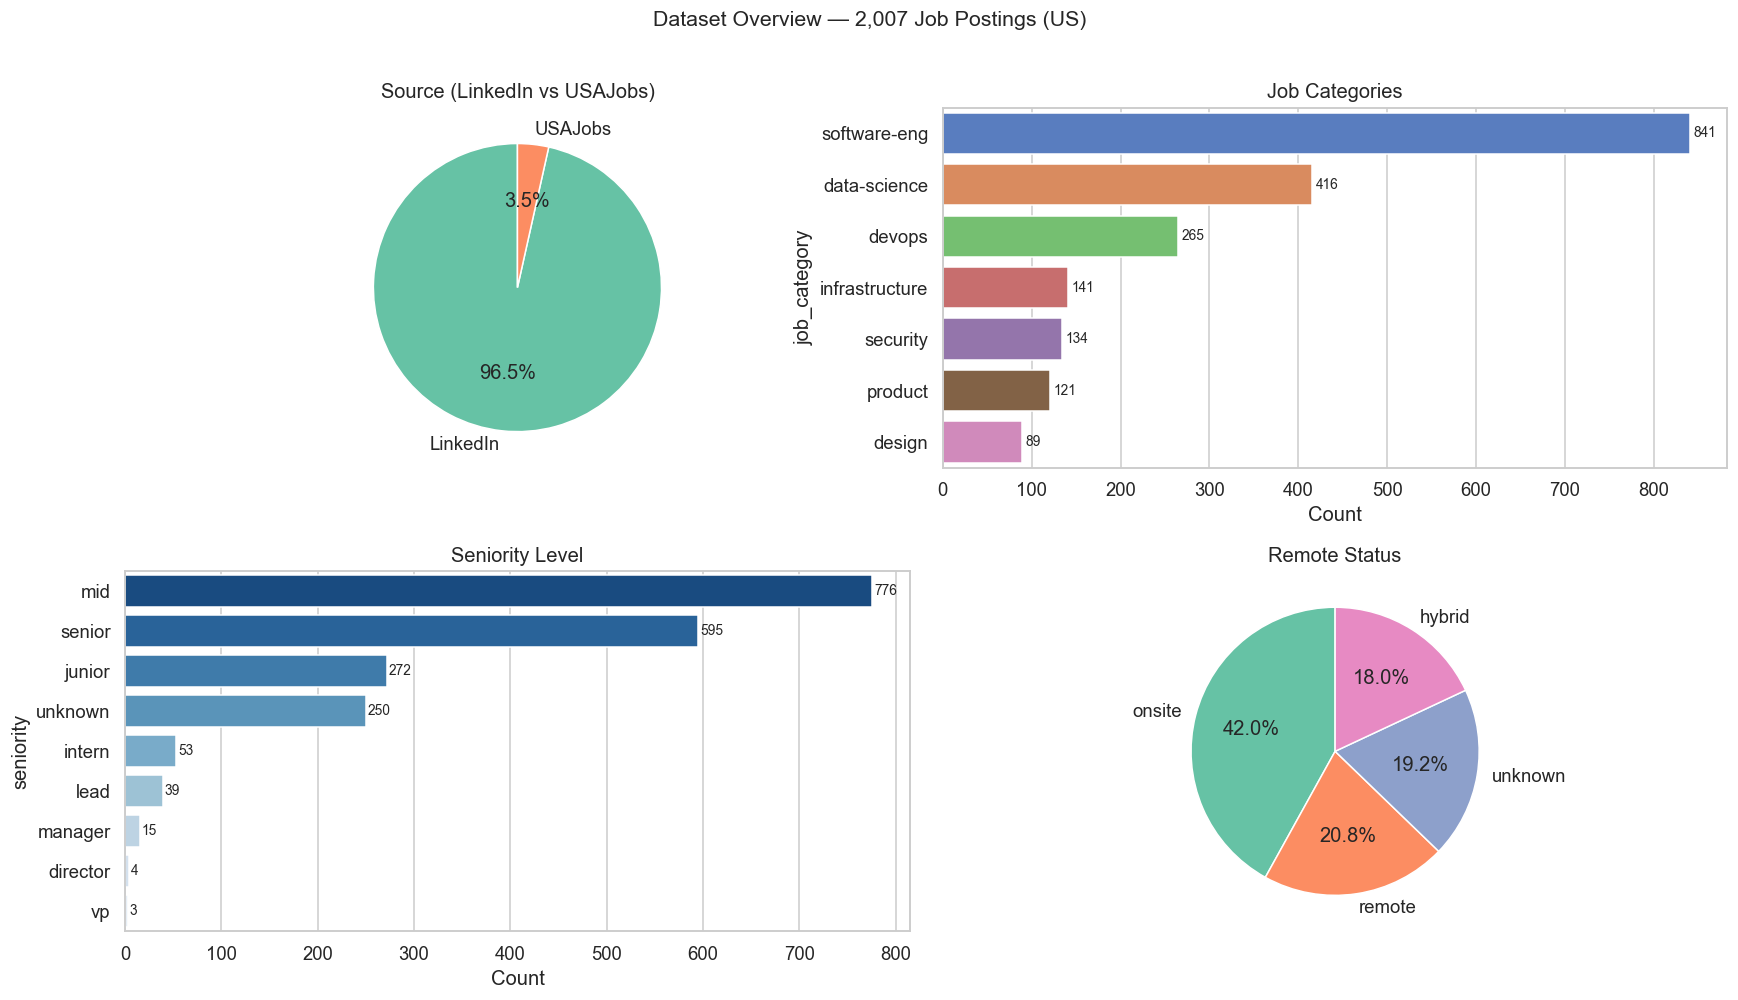

Total postings : 2,007
Date range     : 2025-10-01 → 2026-04-15
Companies      : 1,264 unique


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# Source breakdown
src = df['source'].value_counts()
axes[0][0].pie(src.values, labels=src.index, autopct='%1.1f%%',
               colors=sns.color_palette('Set2', len(src)), startangle=90)
axes[0][0].set_title('Source (LinkedIn vs USAJobs)')

# Category
cat = df['job_category'].value_counts()
sns.barplot(x=cat.values, y=cat.index, ax=axes[0][1], palette='muted')
axes[0][1].set_title('Job Categories')
axes[0][1].set_xlabel('Count')
for p, v in zip(axes[0][1].patches, cat.values):
    axes[0][1].text(p.get_width() + 4, p.get_y() + p.get_height()/2, str(v), va='center', fontsize=9)

# Seniority
sen = df['seniority'].value_counts()
sns.barplot(x=sen.values, y=sen.index, ax=axes[1][0], palette='Blues_r')
axes[1][0].set_title('Seniority Level')
axes[1][0].set_xlabel('Count')
for p, v in zip(axes[1][0].patches, sen.values):
    axes[1][0].text(p.get_width() + 2, p.get_y() + p.get_height()/2, str(v), va='center', fontsize=9)

# Remote
rem = df['remote_status'].value_counts()
axes[1][1].pie(rem.values, labels=rem.index, autopct='%1.1f%%',
               colors=sns.color_palette('Set2', len(rem)), startangle=90)
axes[1][1].set_title('Remote Status')

plt.suptitle(f'Dataset Overview — {len(df):,} Job Postings (US)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f'Total postings : {len(df):,}')
print(f'Date range     : {df["posted_date"].min()} → {df["posted_date"].max()}')
print(f'Companies      : {df["company"].nunique():,} unique')

---
## 2. Job Titles & Category Distribution

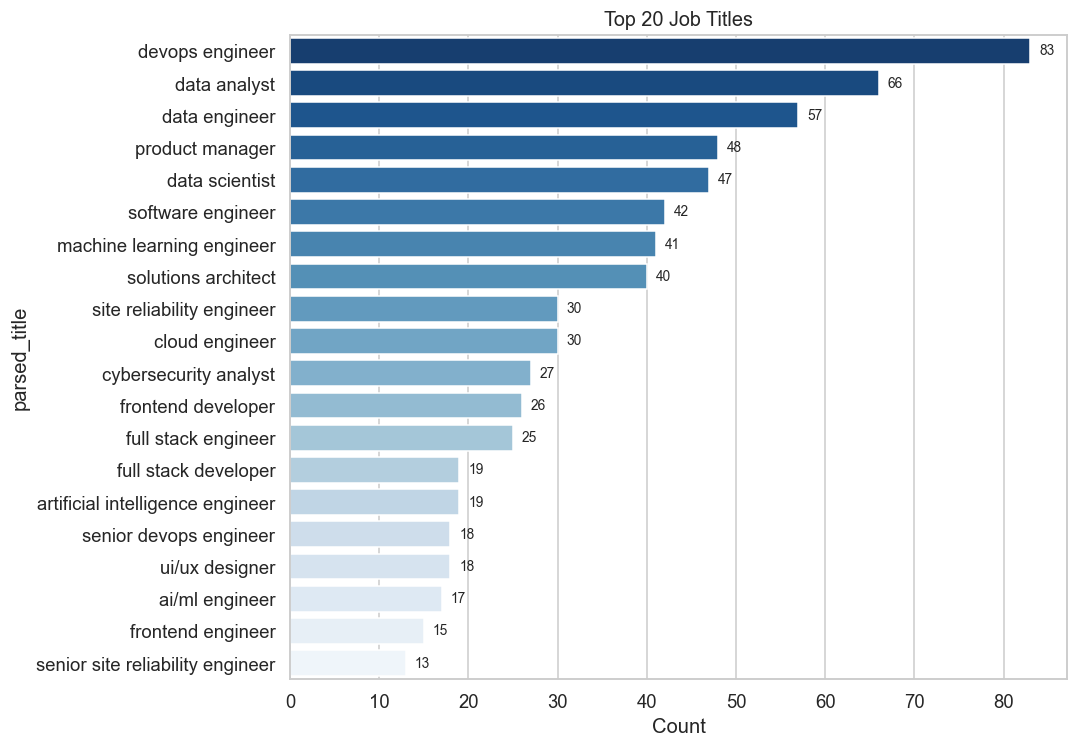

In [4]:
top_titles = df['parsed_title'].str.lower().str.strip().value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=top_titles.values, y=top_titles.index, ax=ax, palette='Blues_r')
ax.set_title('Top 20 Job Titles', fontsize=13)
ax.set_xlabel('Count')
for p, v in zip(ax.patches, top_titles.values):
    ax.text(p.get_width() + 1, p.get_y() + p.get_height()/2, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

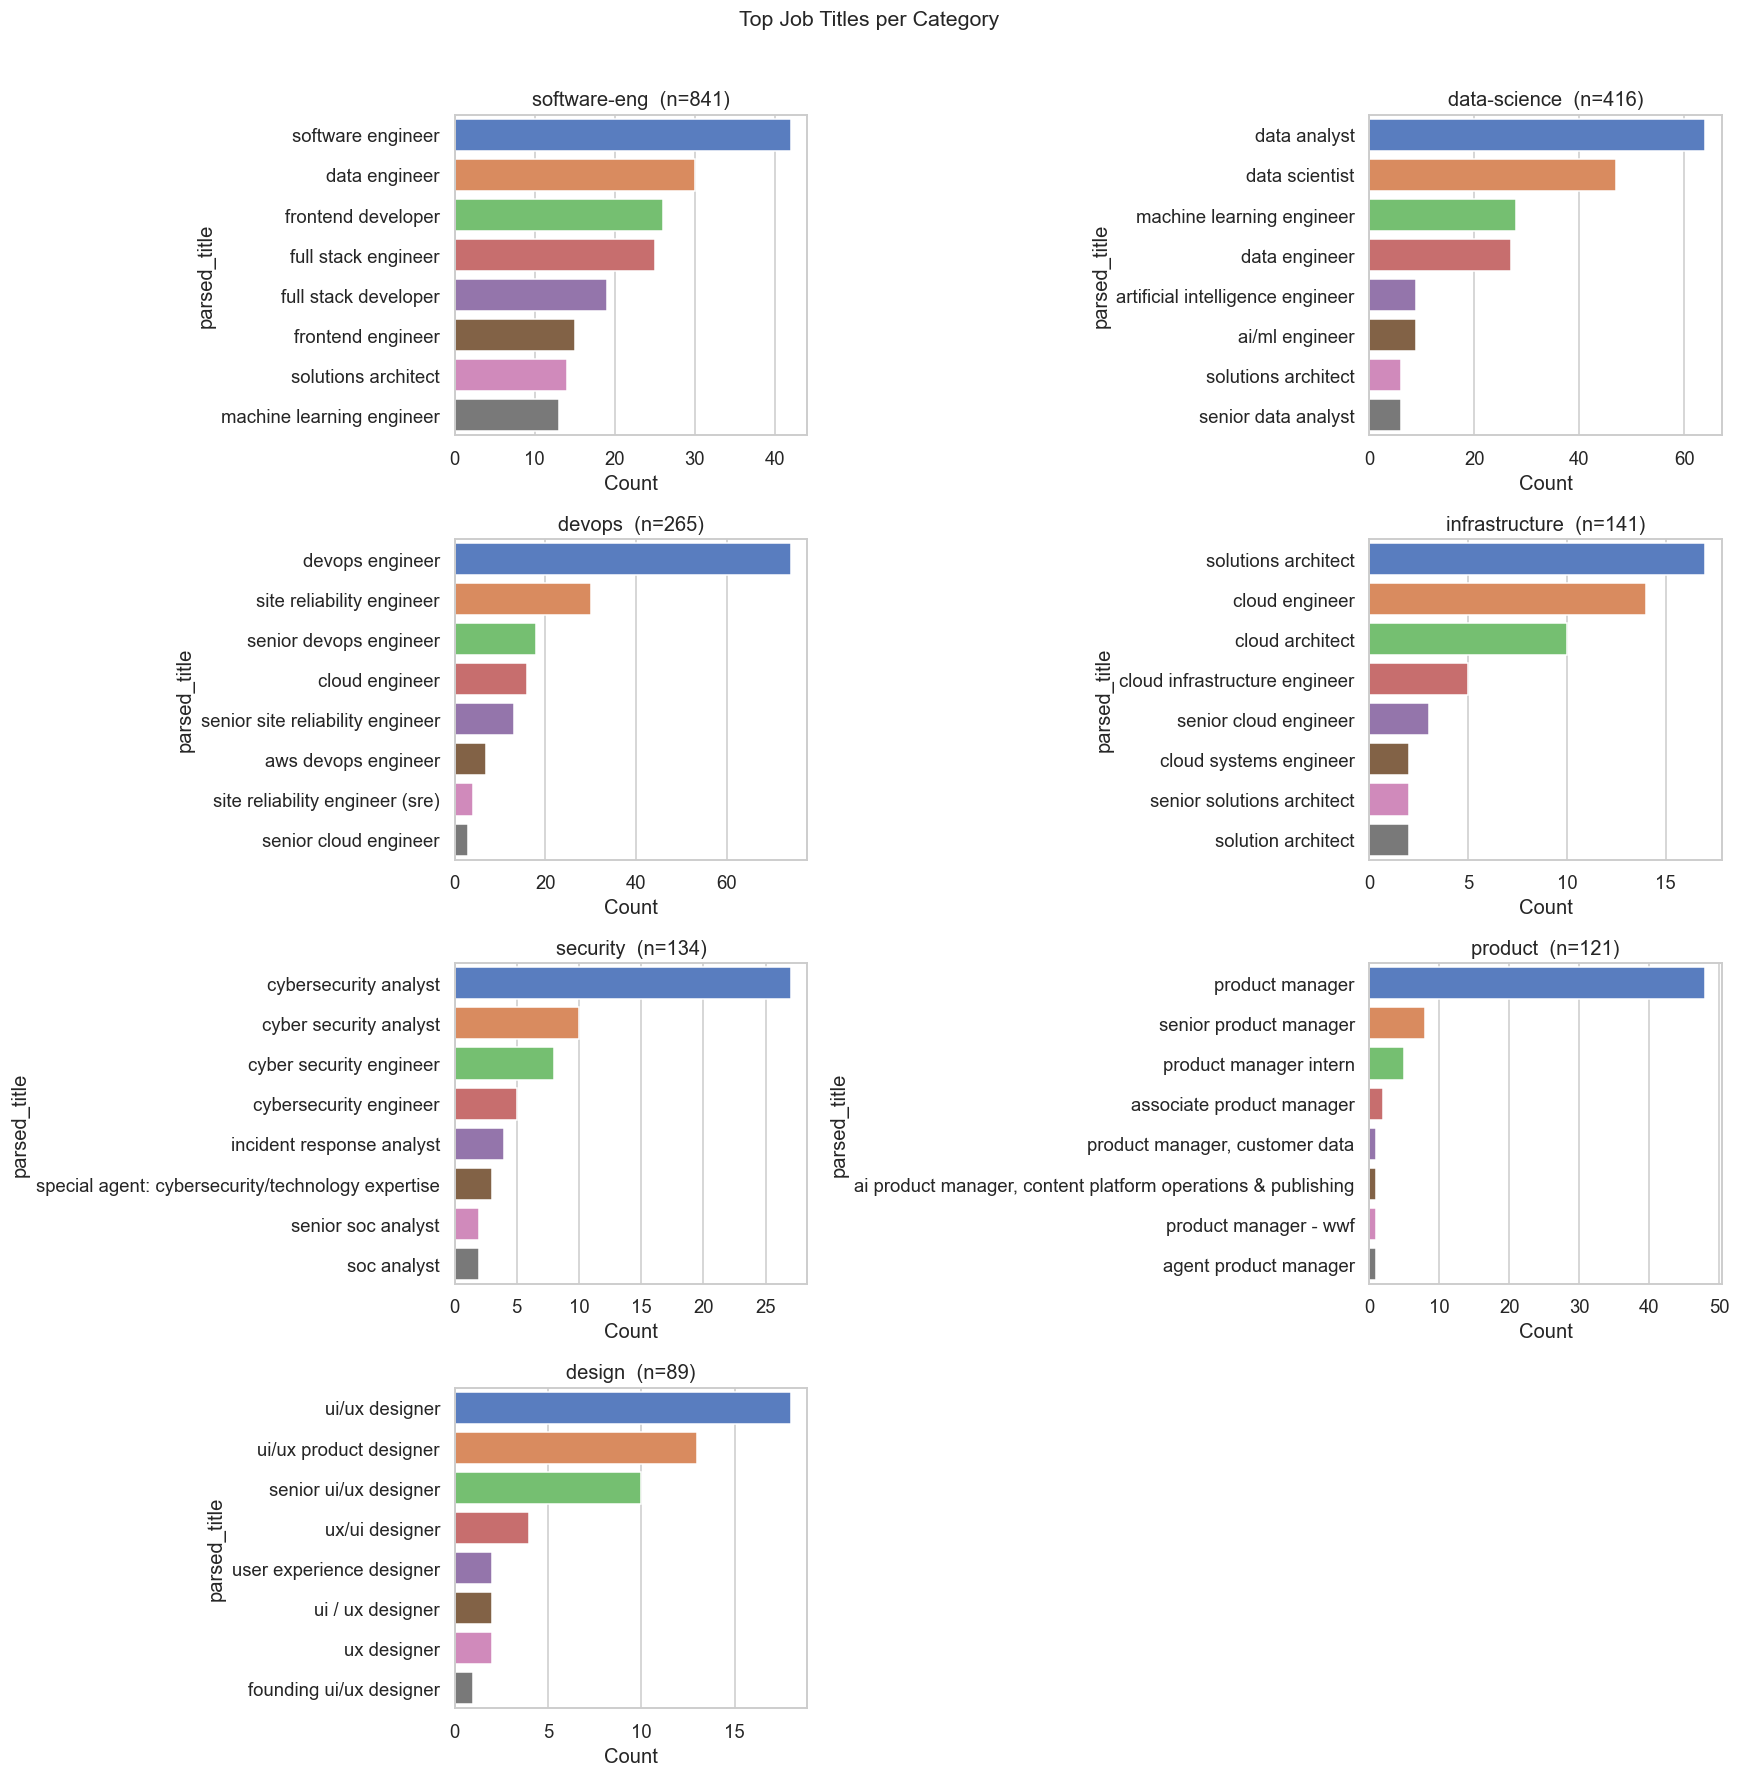

In [5]:
categories = df['job_category'].value_counts().index.tolist()
n_cols = 2
n_rows = -(-len(categories) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, cat in enumerate(categories):
    sub = df[df['job_category'] == cat]
    top = sub['parsed_title'].str.lower().str.strip().value_counts().head(8)
    sns.barplot(x=top.values, y=top.index, ax=axes[i], palette='muted')
    axes[i].set_title(f'{cat}  (n={len(sub):,})')
    axes[i].set_xlabel('Count')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top Job Titles per Category', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

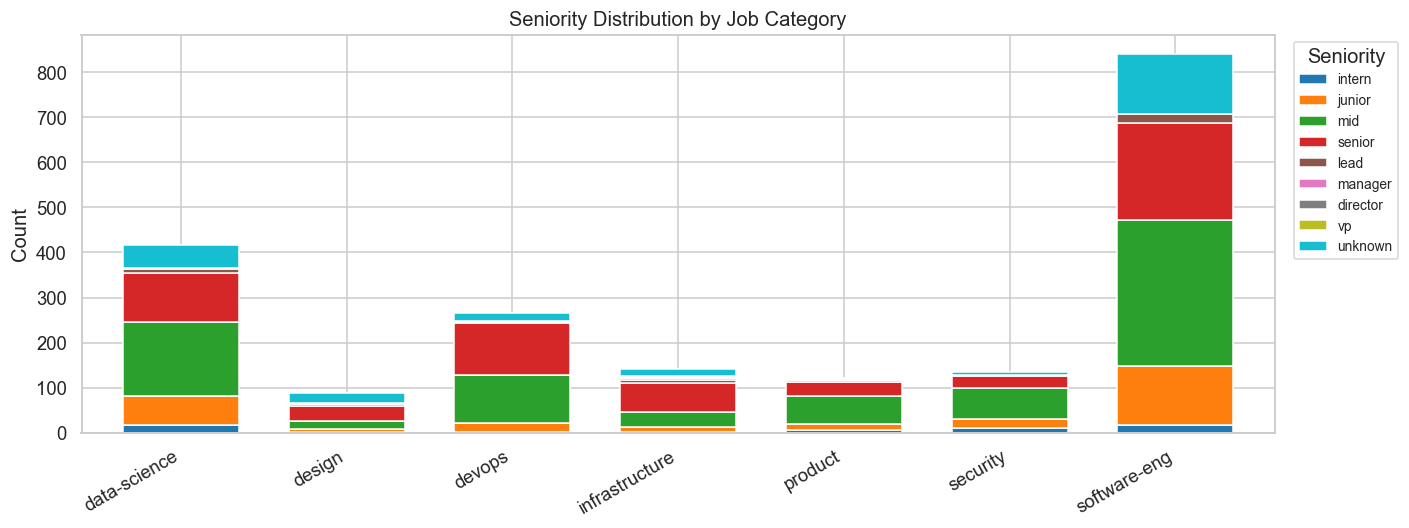

Seniority % by category:
seniority       intern  junior   mid  senior  lead  manager  director   vp  unknown
job_category                                                                       
data-science       3.8    15.9  39.4    26.2   1.9      0.5       0.0  0.0     12.3
design             1.1     9.0  20.2    37.1   4.5      1.1       0.0  1.1     25.8
devops             0.4     7.9  40.4    43.4   0.4      0.8       0.4  0.0      6.4
infrastructure     0.7     8.5  22.7    46.8   3.5      3.5       1.4  1.4     11.3
product            5.8    10.7  51.2    25.6   0.0      4.1       0.8  0.0      1.7
security           7.5    15.7  51.5    18.7   1.5      0.0       0.0  0.0      5.2
software-eng       2.0    15.6  38.5    25.7   2.3      0.0       0.0  0.0     15.9


In [6]:
sen_order = ['intern', 'junior', 'mid', 'senior', 'lead', 'manager', 'director', 'vp', 'unknown']
sen_cat = df.groupby(['job_category', 'seniority']).size().unstack(fill_value=0)
sen_cat = sen_cat[[c for c in sen_order if c in sen_cat.columns]]

ax = sen_cat.plot(kind='bar', stacked=True, figsize=(13, 5), colormap='tab10', width=0.7)
ax.set_title('Seniority Distribution by Job Category')
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.legend(title='Seniority', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

pct = sen_cat.div(sen_cat.sum(axis=1), axis=0).mul(100).round(1)
print('Seniority % by category:')
print(pct.to_string())

---
## 3. Hard Skills — Overall

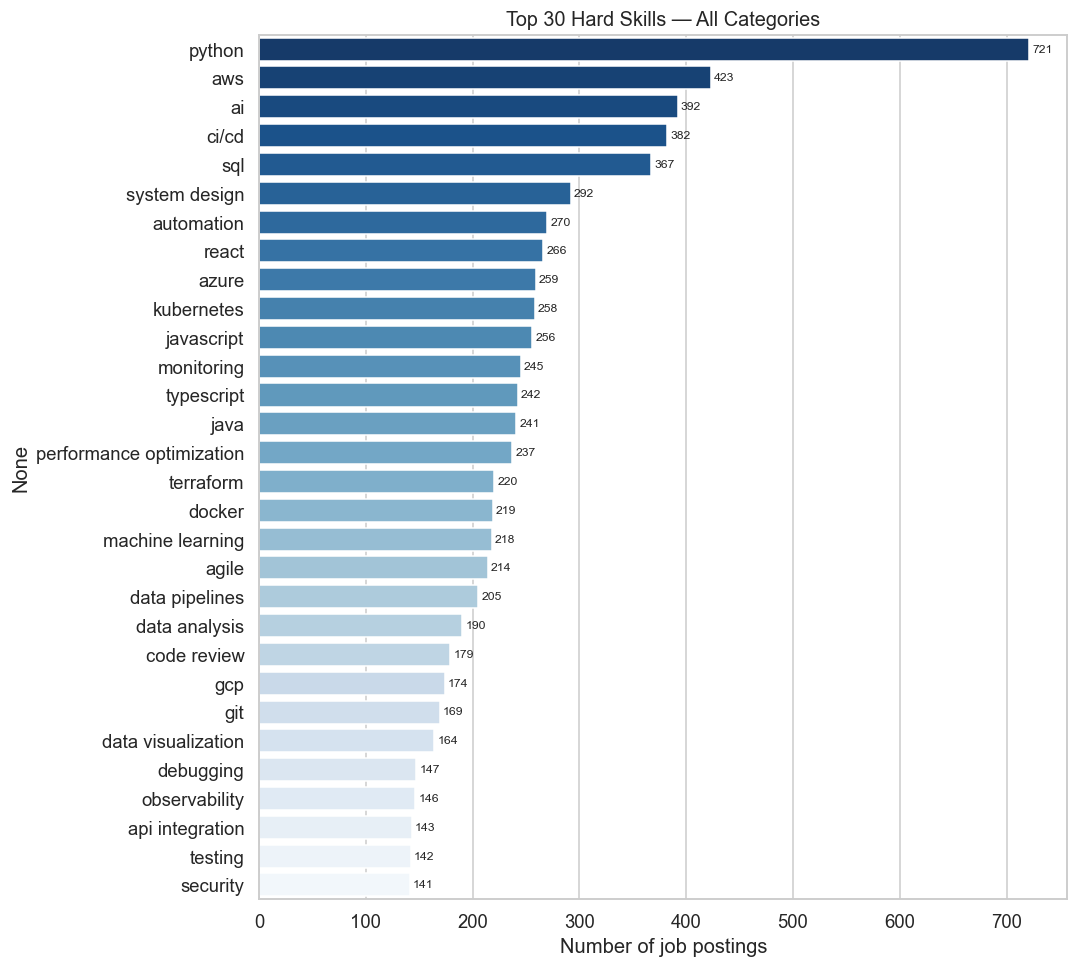

Top 30 Hard Skills with coverage:
  python                               721  (35.9%)
  aws                                  423  (21.1%)
  ai                                   392  (19.5%)
  ci/cd                                382  (19.0%)
  sql                                  367  (18.3%)
  system design                        292  (14.5%)
  automation                           270  (13.5%)
  react                                266  (13.3%)
  azure                                259  (12.9%)
  kubernetes                           258  (12.9%)
  javascript                           256  (12.8%)
  monitoring                           245  (12.2%)
  typescript                           242  (12.1%)
  java                                 241  (12.0%)
  performance optimization             237  (11.8%)
  terraform                            220  (11.0%)
  docker                               219  (10.9%)
  machine learning                     218  (10.9%)
  agile                       

In [7]:
hard_top30 = top_n(df['hard_skills'], n=30)

fig, ax = plt.subplots(figsize=(10, 9))
sns.barplot(x=hard_top30.values, y=hard_top30.index, ax=ax, palette='Blues_r')
ax.set_title('Top 30 Hard Skills — All Categories', fontsize=13)
ax.set_xlabel('Number of job postings')
for p, v in zip(ax.patches, hard_top30.values):
    ax.text(p.get_width() + 3, p.get_y() + p.get_height()/2, str(v), va='center', fontsize=8)
plt.tight_layout()
plt.show()

print('Top 30 Hard Skills with coverage:')
for skill, cnt in hard_top30.items():
    print(f'  {skill:<35} {cnt:>4}  ({cnt/len(df)*100:.1f}%)')

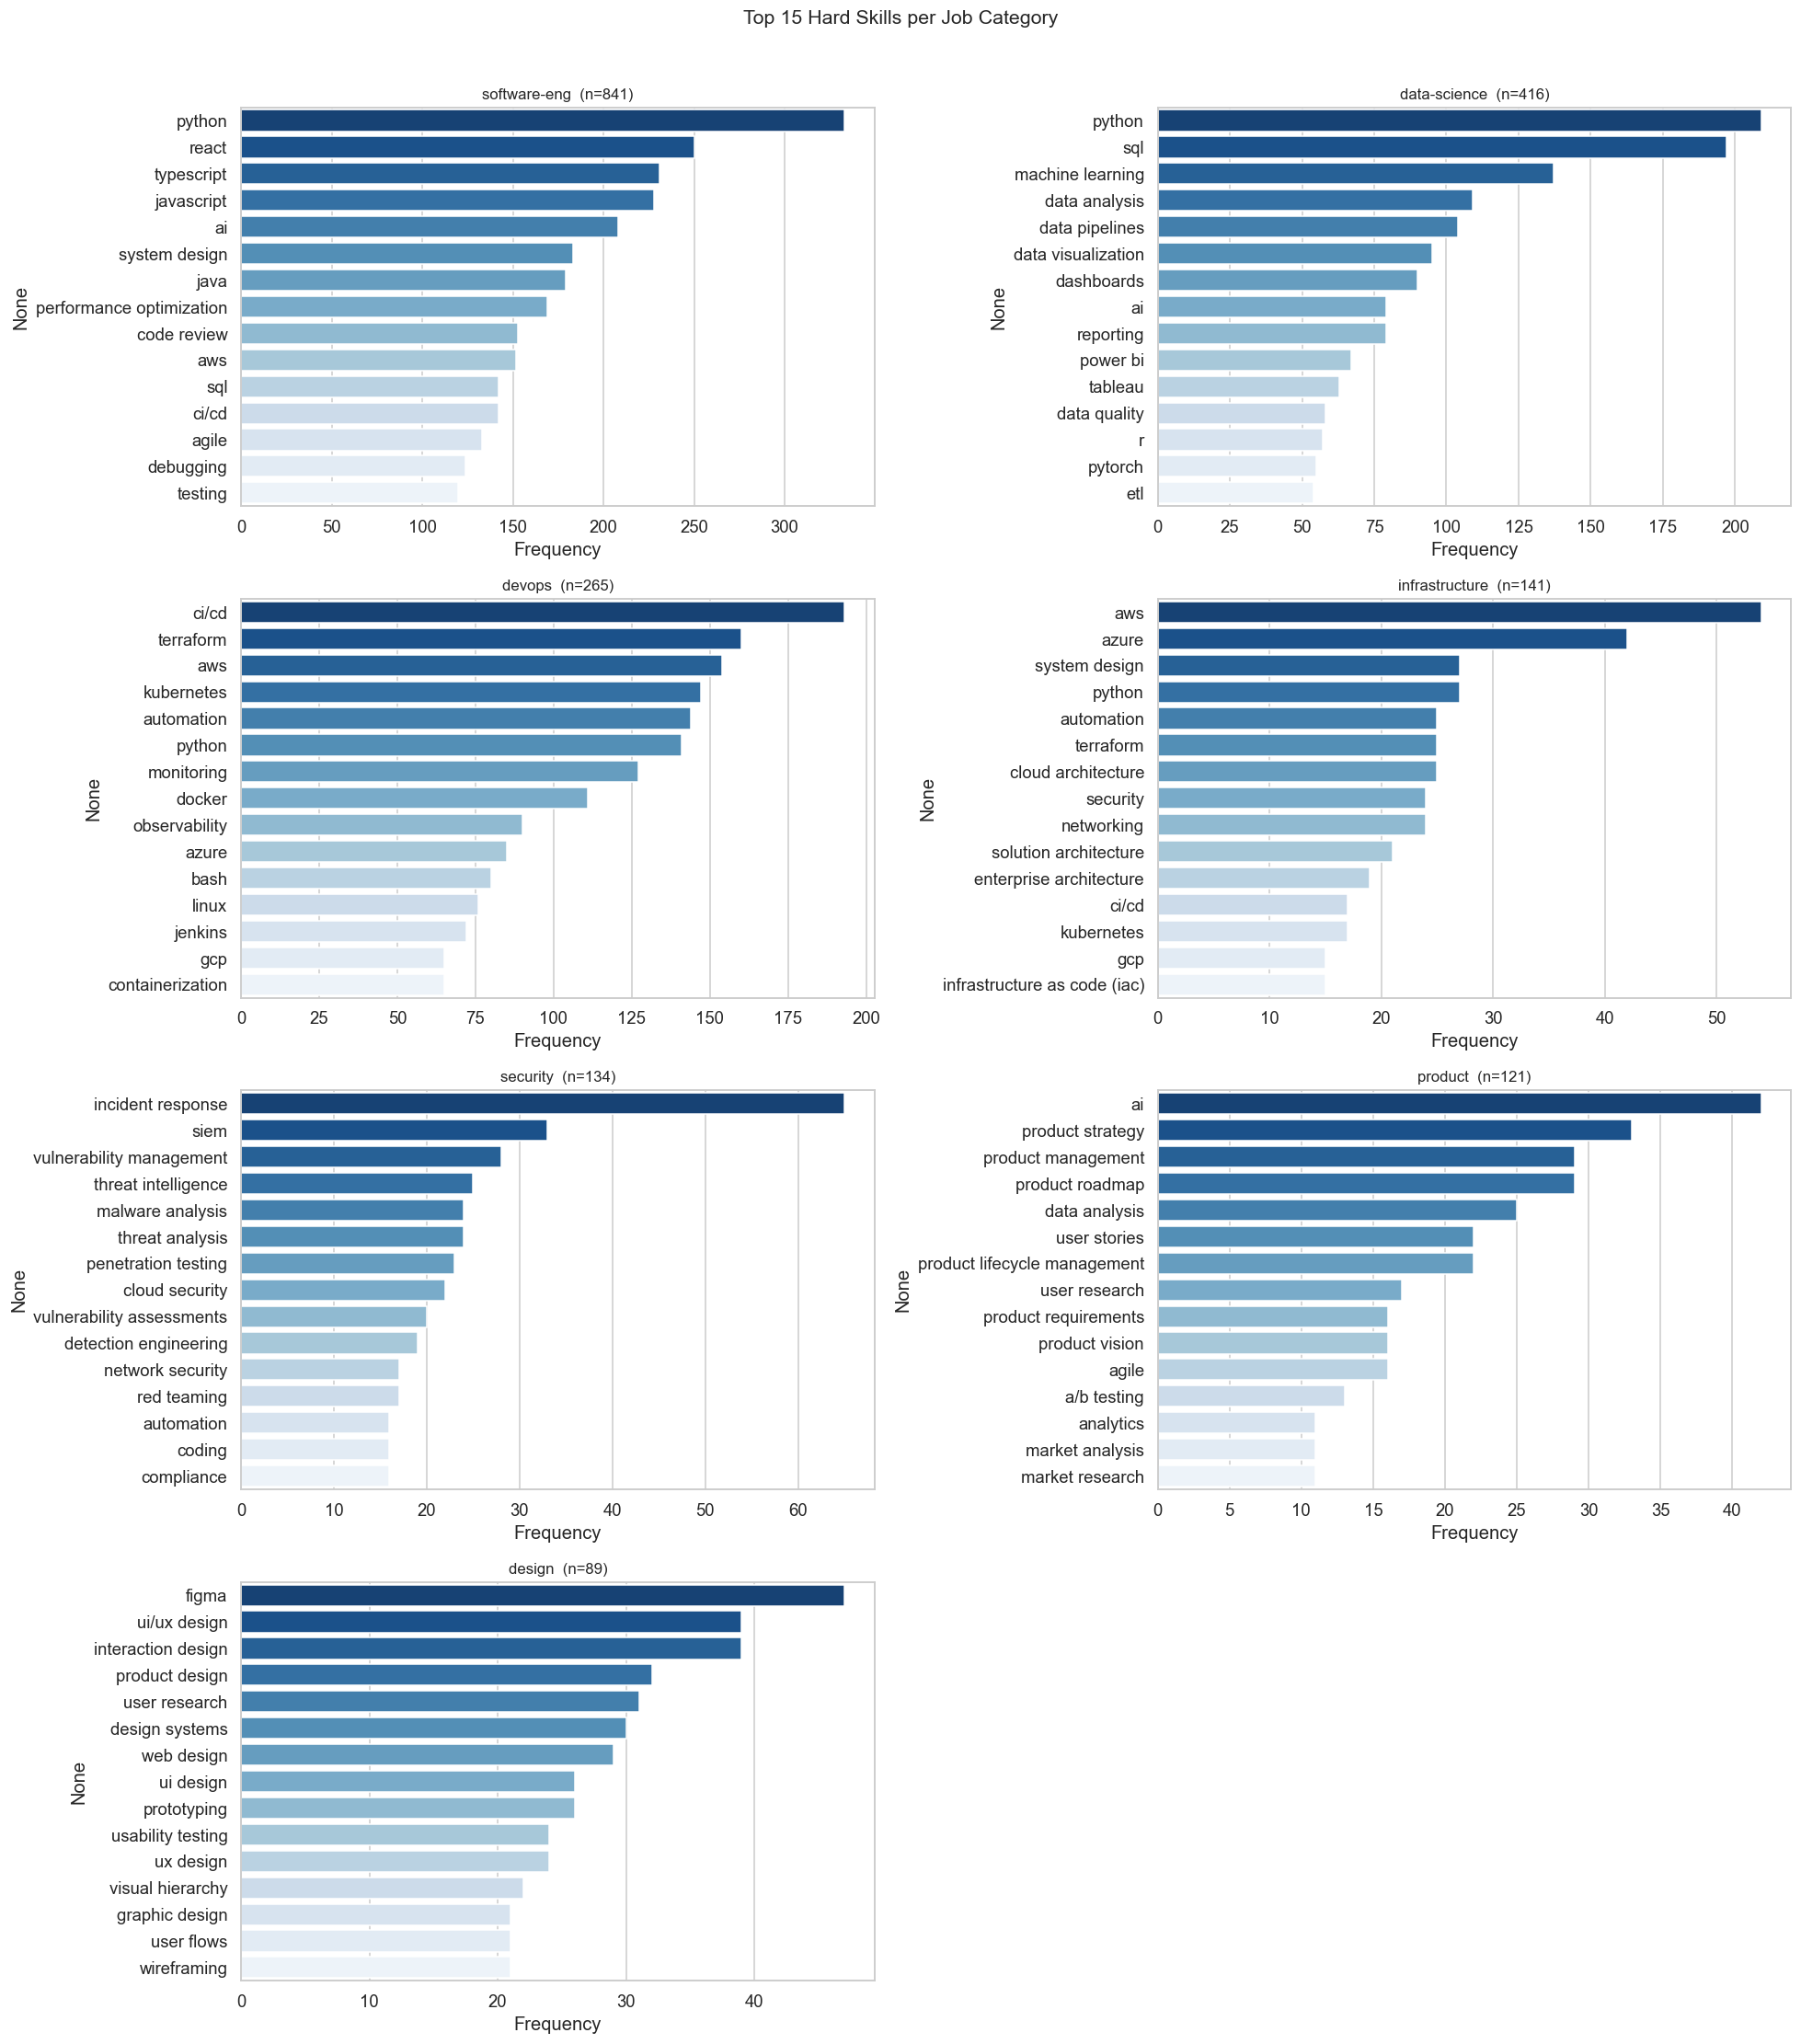

In [8]:
categories = df['job_category'].value_counts().index.tolist()
n_cols = 2
n_rows = -(-len(categories) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i, cat in enumerate(categories):
    sub = df[df['job_category'] == cat]
    top = top_n(sub['hard_skills'], n=15)
    sns.barplot(x=top.values, y=top.index, ax=axes[i], palette='Blues_r')
    axes[i].set_title(f'{cat}  (n={len(sub):,})', fontsize=11)
    axes[i].set_xlabel('Frequency')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top 15 Hard Skills per Job Category', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Hard skill count stats by category:
                mean  median  min  max
job_category                          
devops          26.0    24.0    4   77
security        16.6    16.0    1   37
infrastructure  17.3    16.0    1   52
software-eng    18.0    16.0    1   52
data-science    16.5    15.0    1   53
design          14.3    13.0    7   30
product         12.6    12.0    1   26


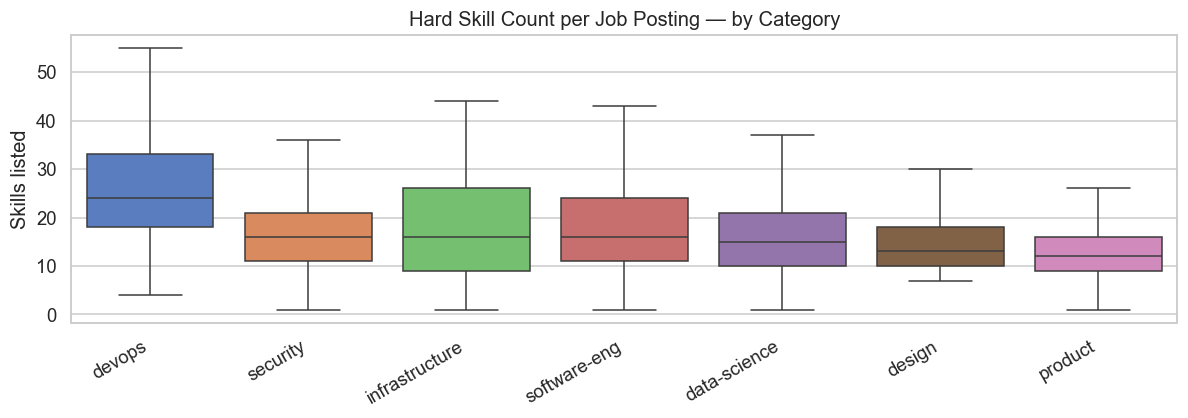

In [9]:
df['n_hard'] = df['hard_skills'].apply(
    lambda x: len([s for s in str(x).split(',') if s.strip()]) if pd.notna(x) else 0
)

print('Hard skill count stats by category:')
stats = df.groupby('job_category')['n_hard'].agg(['mean', 'median', 'min', 'max']).round(1)
print(stats.sort_values('median', ascending=False).to_string())

fig, ax = plt.subplots(figsize=(11, 4))
order = df.groupby('job_category')['n_hard'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='job_category', y='n_hard', order=order,
            ax=ax, palette='muted', showfliers=False)
ax.set_title('Hard Skill Count per Job Posting — by Category')
ax.set_xlabel('')
ax.set_ylabel('Skills listed')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## 4. Most In-Demand & Most Essential Skills

**In-Demand** = tần suất xuất hiện cao (tuyệt đối)

**Essential** = xuất hiện rộng trên nhiều ngành khác nhau
→ Skills mà ngành nào cũng cần = nền tảng quan trọng nhất cho career

**Essential score** = `frequency × n_categories` (nhiều + rộng = thiết yếu nhất)

In [10]:
total_cnt = Counter(parse_skills(df['hard_skills']))
n_cats = df['job_category'].nunique()
all_cats = df['job_category'].unique().tolist()

# For each skill: count how many distinct categories it appears in
skill_cat_sets = {}
for _, row in df[df['hard_skills'].notna()].iterrows():
    for sk in str(row['hard_skills']).split(','):
        sk = sk.strip().lower()
        if sk:
            skill_cat_sets.setdefault(sk, set()).add(row['job_category'])

# Build summary DataFrame
rows = []
for sk, cnt in total_cnt.items():
    n_cat = len(skill_cat_sets.get(sk, set()))
    rows.append({'skill': sk, 'frequency': cnt, 'n_categories': n_cat,
                 'coverage_pct': round(cnt / len(df) * 100, 1),
                 'essential_score': cnt * n_cat})

skill_df = pd.DataFrame(rows).sort_values('essential_score', ascending=False)

print(f'Total unique hard skills: {len(skill_df):,}')
print()
print('Top 20 Most Essential Skills (freq × n_categories):')
top_ess = skill_df[skill_df['frequency'] >= 5].head(20)
print(top_ess[['skill', 'frequency', 'n_categories', 'coverage_pct', 'essential_score']].to_string(index=False))

Total unique hard skills: 7,372

Top 20 Most Essential Skills (freq × n_categories):
                   skill  frequency  n_categories  coverage_pct  essential_score
                  python        721             6          35.9             4326
                     aws        423             7          21.1             2961
                      ai        392             7          19.5             2744
                   ci/cd        382             7          19.0             2674
                     sql        367             7          18.3             2569
              automation        270             7          13.5             1890
           system design        292             6          14.5             1752
              kubernetes        258             6          12.9             1548
              javascript        256             6          12.8             1536
                   agile        214             7          10.7             1498
              monitoring

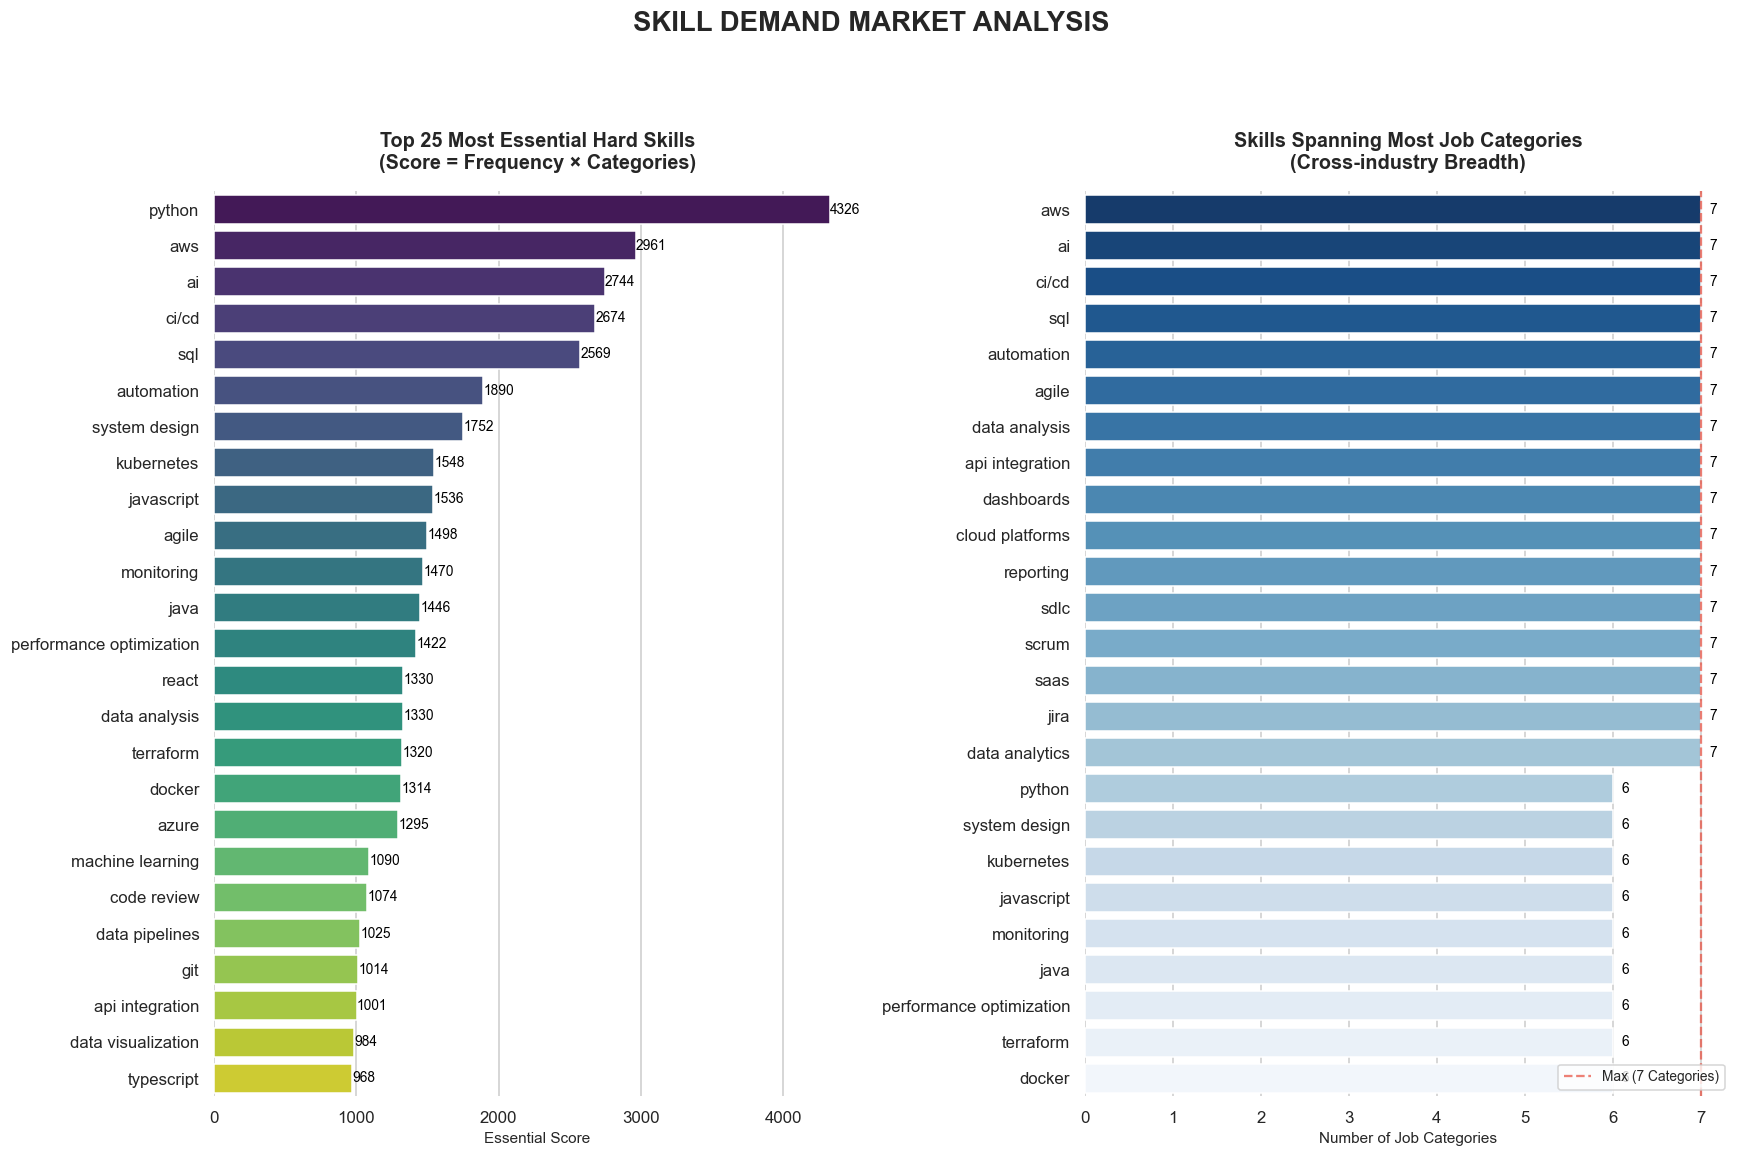

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

top_ess25 = top_ess25.sort_values('essential_score', ascending=False)

sns.barplot(
    x='essential_score', 
    y='skill', 
    data=top_ess25,
    ax=axes[0], 
    palette='viridis',
    hue='skill', 
    legend=False
)

axes[0].set_title('Top 25 Most Essential Hard Skills\n(Score = Frequency × Categories)', fontsize=13, pad=15, fontweight='bold')
axes[0].set_xlabel('Essential Score', fontsize=10)
axes[0].set_ylabel('', fontsize=10) 

for p in axes[0].patches:
    width = p.get_width()
    axes[0].text(width + 3, p.get_y() + p.get_height()/2, f'{int(width)}', 
                 va='center', fontsize=9, color='black')

top_broad = top_broad.sort_values('n_categories', ascending=False)

sns.barplot(
    x='n_categories', 
    y='skill', 
    data=top_broad,
    ax=axes[1], 
    palette='Blues_r', 
    hue='skill', 
    legend=False
)

axes[1].set_title('Skills Spanning Most Job Categories\n(Cross-industry Breadth)', fontsize=13, pad=15, fontweight='bold')
axes[1].set_xlabel('Number of Job Categories', fontsize=10)
axes[1].set_ylabel('')

axes[1].axvline(n_cats, color='#e74c3c', lw=1.5, ls='--', alpha=0.7, label=f'Max ({n_cats} Categories)')
axes[1].legend(loc='lower right', fontsize=9)

for p in axes[1].patches:
    width = p.get_width()
    axes[1].text(width + 0.1, p.get_y() + p.get_height()/2, f'{int(width)}', 
                 va='center', fontsize=9, color='black')

sns.despine(left=True, bottom=True) 
plt.suptitle('SKILL DEMAND MARKET ANALYSIS', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

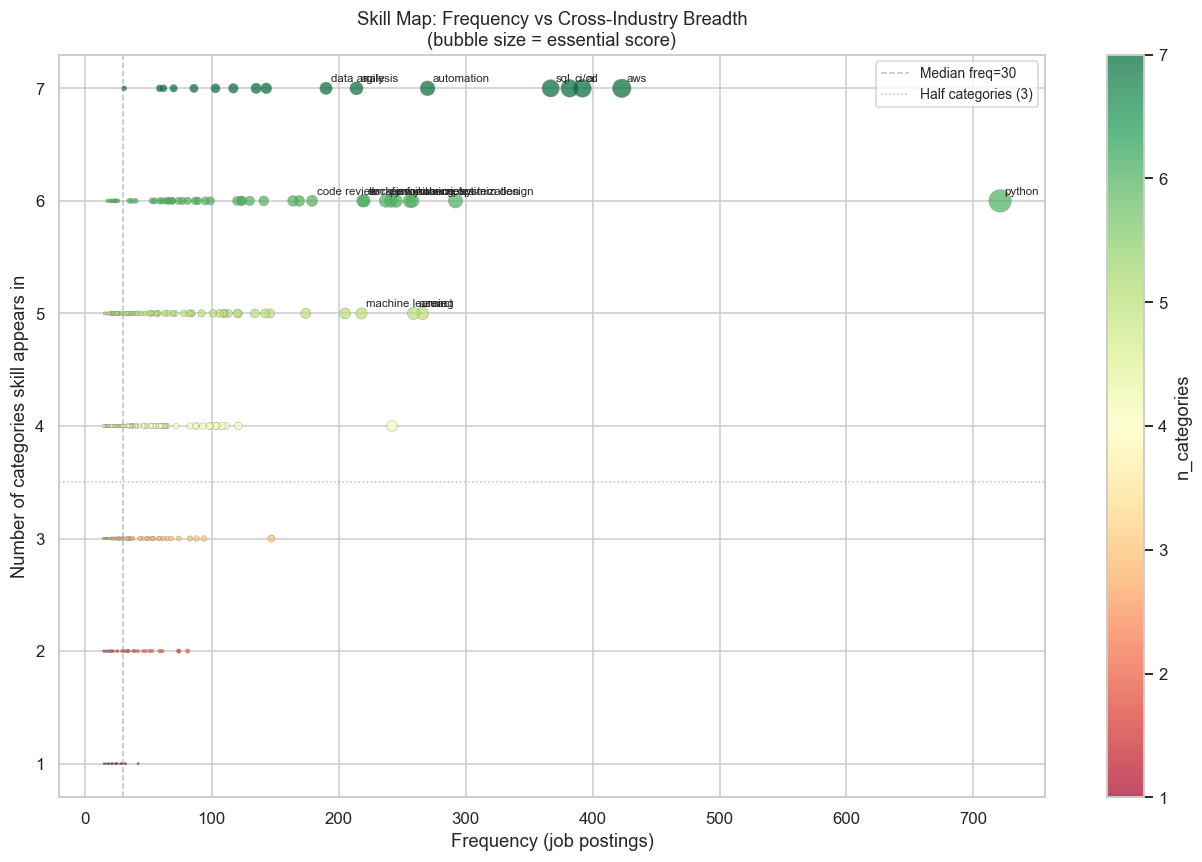


Skills appearing in ALL categories:
          skill  frequency  coverage_pct
            aws        423          21.1
             ai        392          19.5
          ci/cd        382          19.0
            sql        367          18.3
     automation        270          13.5
          agile        214          10.7
  data analysis        190           9.5
api integration        143           7.1
     dashboards        135           6.7
cloud platforms        117           5.8
      reporting        103           5.1
           sdlc         86           4.3
          scrum         70           3.5
           saas         62           3.1
           jira         59           2.9
 data analytics         31           1.5

Skills appearing in all-but-one categories:
                   skill  frequency  n_categories
                  python        721             6
                     aws        423             7
                      ai        392             7
                   ci

In [28]:
# Scatter: frequency vs breadth — the "must-have" quadrant
plot_df = skill_df[skill_df['frequency'] >= 15].copy()

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(plot_df['frequency'], plot_df['n_categories'],
                     s=plot_df['essential_score'] / 20,
                     c=plot_df['n_categories'], cmap='RdYlGn',
                     alpha=0.7, edgecolors='gray', linewidths=0.3)

# Label top skills
top_label = plot_df.nlargest(20, 'essential_score')
for _, row in top_label.iterrows():
    ax.annotate(row['skill'], (row['frequency'], row['n_categories']),
                fontsize=7.5, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points')

median_freq = plot_df['frequency'].median()
ax.axvline(median_freq, color='gray', lw=1, ls='--', alpha=0.5, label=f'Median freq={median_freq:.0f}')
ax.axhline(n_cats / 2, color='gray', lw=1, ls=':', alpha=0.5, label=f'Half categories ({n_cats//2})')

plt.colorbar(scatter, ax=ax, label='n_categories')
ax.set_xlabel('Frequency (job postings)')
ax.set_ylabel('Number of categories skill appears in')
ax.set_title('Skill Map: Frequency vs Cross-Industry Breadth\n(bubble size = essential score)', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('\nSkills appearing in ALL categories:')
all_cat_skills = skill_df[skill_df['n_categories'] == n_cats][['skill', 'frequency', 'coverage_pct']]
print(all_cat_skills.to_string(index=False) if len(all_cat_skills) else '  (none)')
print()
print('Skills appearing in all-but-one categories:')
near_all = skill_df[skill_df['n_categories'] >= n_cats - 1][['skill', 'frequency', 'n_categories']]
print(near_all.head(15).to_string(index=False))

---
## 5. Hard Skills by Seniority Level

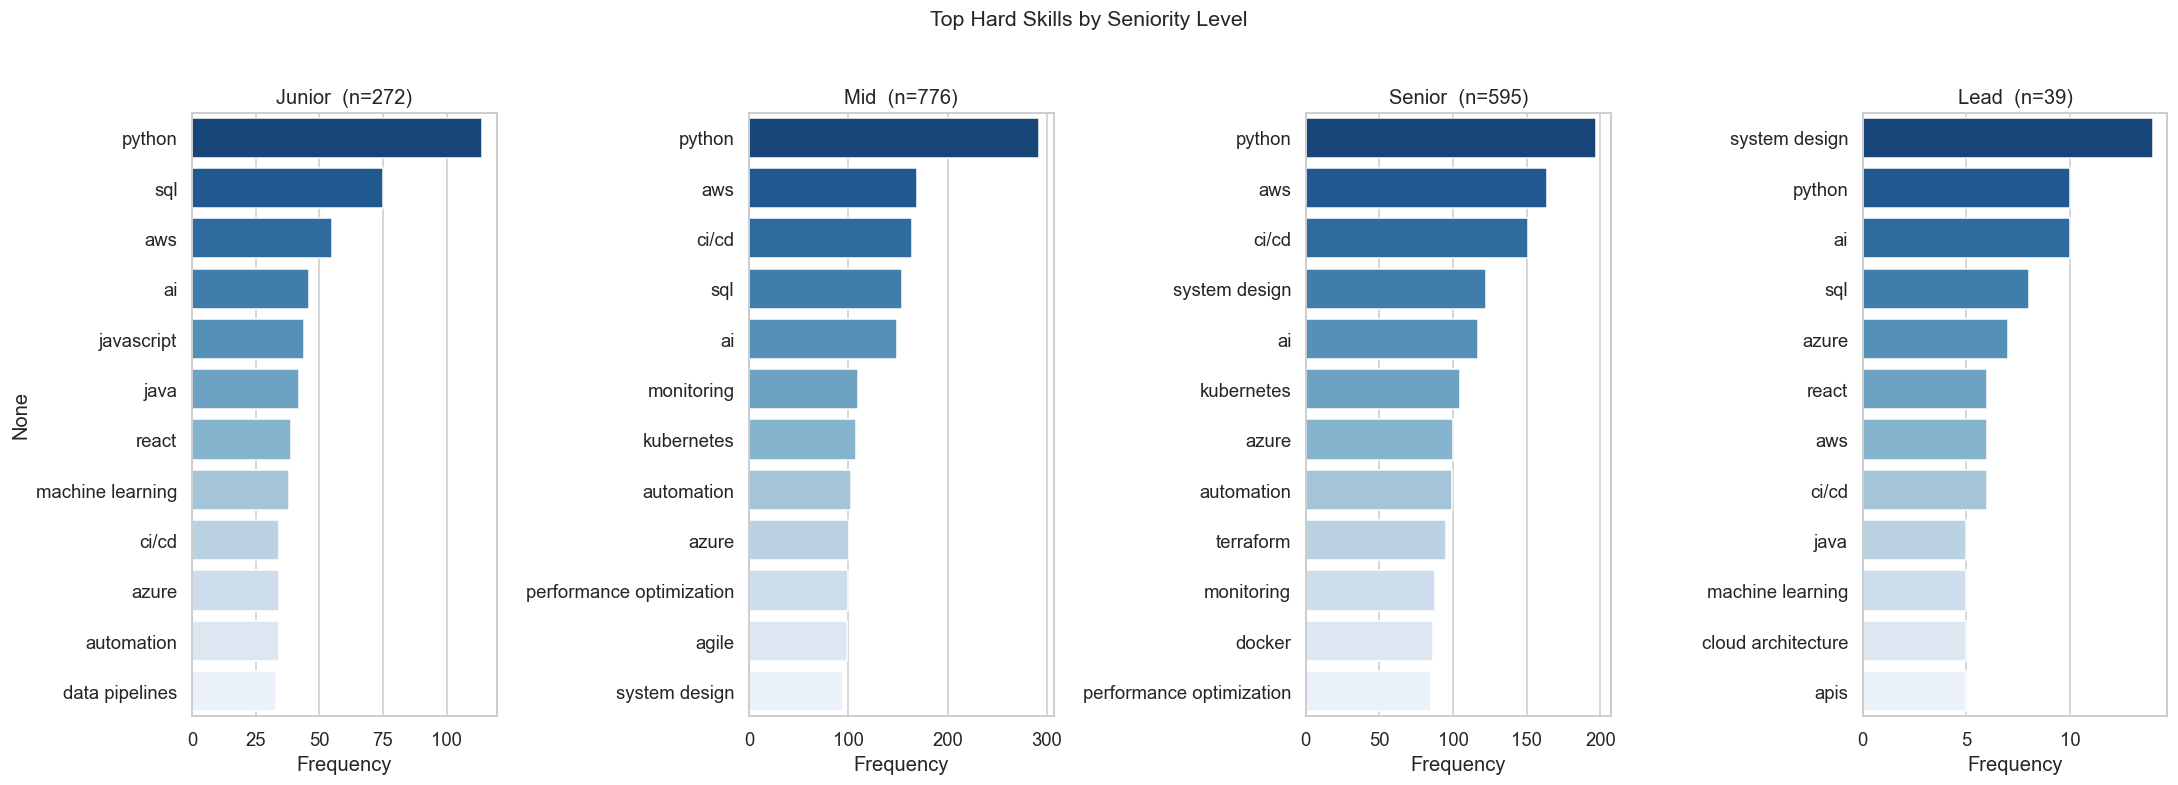

In [13]:
levels = ['junior', 'mid', 'senior', 'lead']
levels = [l for l in levels if (df['seniority'] == l).sum() > 10]

fig, axes = plt.subplots(1, len(levels), figsize=(5 * len(levels), 7))

for i, level in enumerate(levels):
    sub = df[df['seniority'] == level]
    top = top_n(sub['hard_skills'], n=12)
    sns.barplot(x=top.values, y=top.index, ax=axes[i], palette='Blues_r')
    axes[i].set_title(f'{level.title()}  (n={len(sub):,})')
    axes[i].set_xlabel('Frequency')
    if i > 0:
        axes[i].set_ylabel('')

plt.suptitle('Top Hard Skills by Seniority Level', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

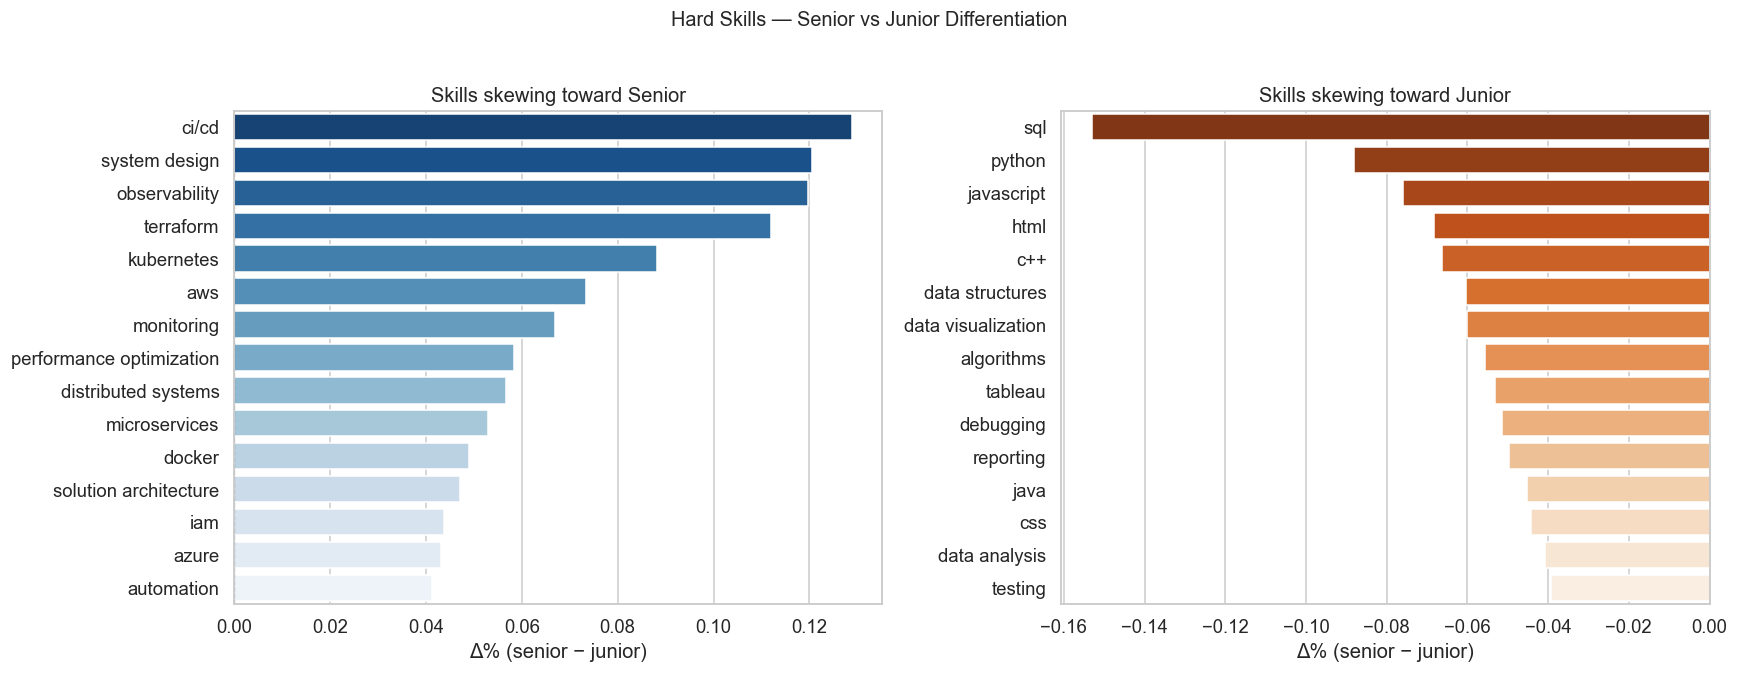

In [14]:
c_j = Counter(parse_skills(df[df['seniority'] == 'junior']['hard_skills']))
c_s = Counter(parse_skills(df[df['seniority'] == 'senior']['hard_skills']))
n_j = (df['seniority'] == 'junior').sum()
n_s = (df['seniority'] == 'senior').sum()

diffs = {}
for sk in set(c_j) | set(c_s):
    j_pct = c_j.get(sk, 0) / n_j
    s_pct = c_s.get(sk, 0) / n_s
    if j_pct + s_pct >= 0.02:
        diffs[sk] = s_pct - j_pct

senior_lean = sorted(diffs.items(), key=lambda x: -x[1])[:15]
junior_lean = sorted(diffs.items(), key=lambda x:  x[1])[:15]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sk, vals = zip(*senior_lean)
sns.barplot(x=list(vals), y=list(sk), ax=axes[0], palette='Blues_r')
axes[0].set_title('Skills skewing toward Senior')
axes[0].set_xlabel('Δ% (senior − junior)')
axes[0].axvline(0, color='gray', lw=0.8, ls='--')

sk, vals = zip(*junior_lean)
sns.barplot(x=list(vals), y=list(sk), ax=axes[1], palette='Oranges_r')
axes[1].set_title('Skills skewing toward Junior')
axes[1].set_xlabel('Δ% (senior − junior)')
axes[1].axvline(0, color='gray', lw=0.8, ls='--')

plt.suptitle('Hard Skills — Senior vs Junior Differentiation', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Soft Skills Analysis

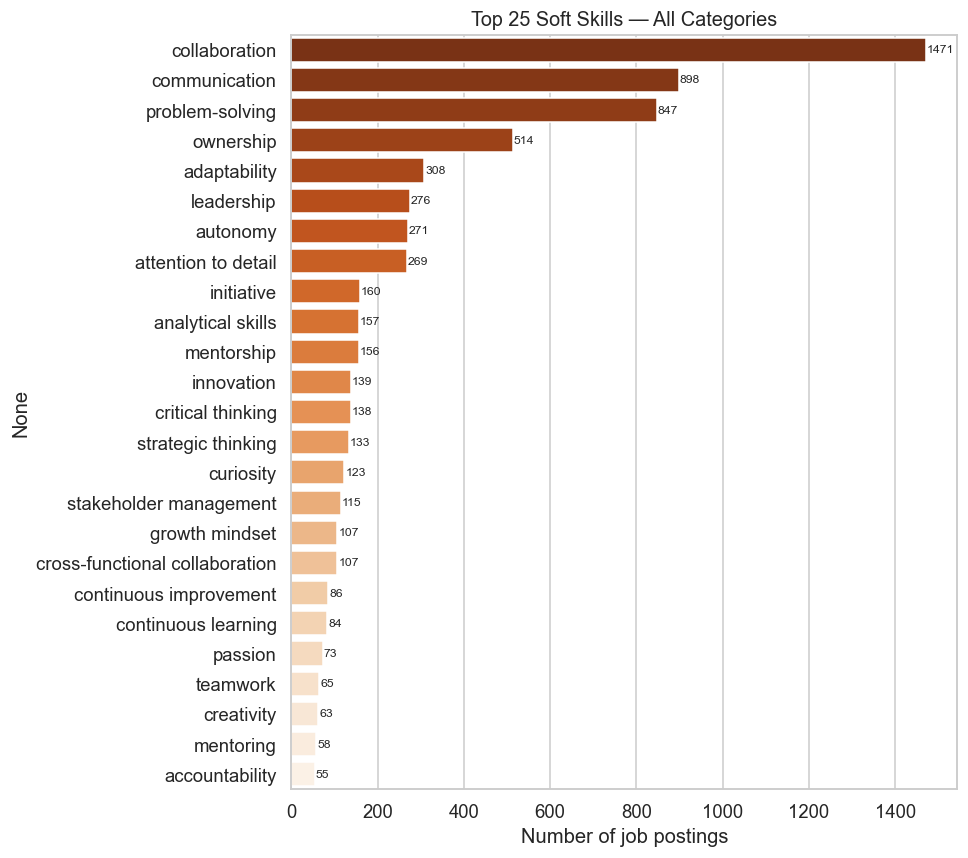

Top 25 Soft Skills:
  collaboration                       1471  (73.3%)
  communication                        898  (44.7%)
  problem-solving                      847  (42.2%)
  ownership                            514  (25.6%)
  adaptability                         308  (15.3%)
  leadership                           276  (13.8%)
  autonomy                             271  (13.5%)
  attention to detail                  269  (13.4%)
  initiative                           160  (8.0%)
  analytical skills                    157  (7.8%)
  mentorship                           156  (7.8%)
  innovation                           139  (6.9%)
  critical thinking                    138  (6.9%)
  strategic thinking                   133  (6.6%)
  curiosity                            123  (6.1%)
  stakeholder management               115  (5.7%)
  growth mindset                       107  (5.3%)
  cross-functional collaboration       107  (5.3%)
  continuous improvement                86  (4.3%)
  c

In [15]:
soft_top25 = top_n(df['soft_skills'], n=25)

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(x=soft_top25.values, y=soft_top25.index, ax=ax, palette='Oranges_r')
ax.set_title('Top 25 Soft Skills — All Categories', fontsize=13)
ax.set_xlabel('Number of job postings')
for p, v in zip(ax.patches, soft_top25.values):
    ax.text(p.get_width() + 2, p.get_y() + p.get_height()/2, str(v), va='center', fontsize=8)
plt.tight_layout()
plt.show()

print('Top 25 Soft Skills:')
for skill, cnt in soft_top25.items():
    print(f'  {skill:<35} {cnt:>4}  ({cnt/len(df)*100:.1f}%)')

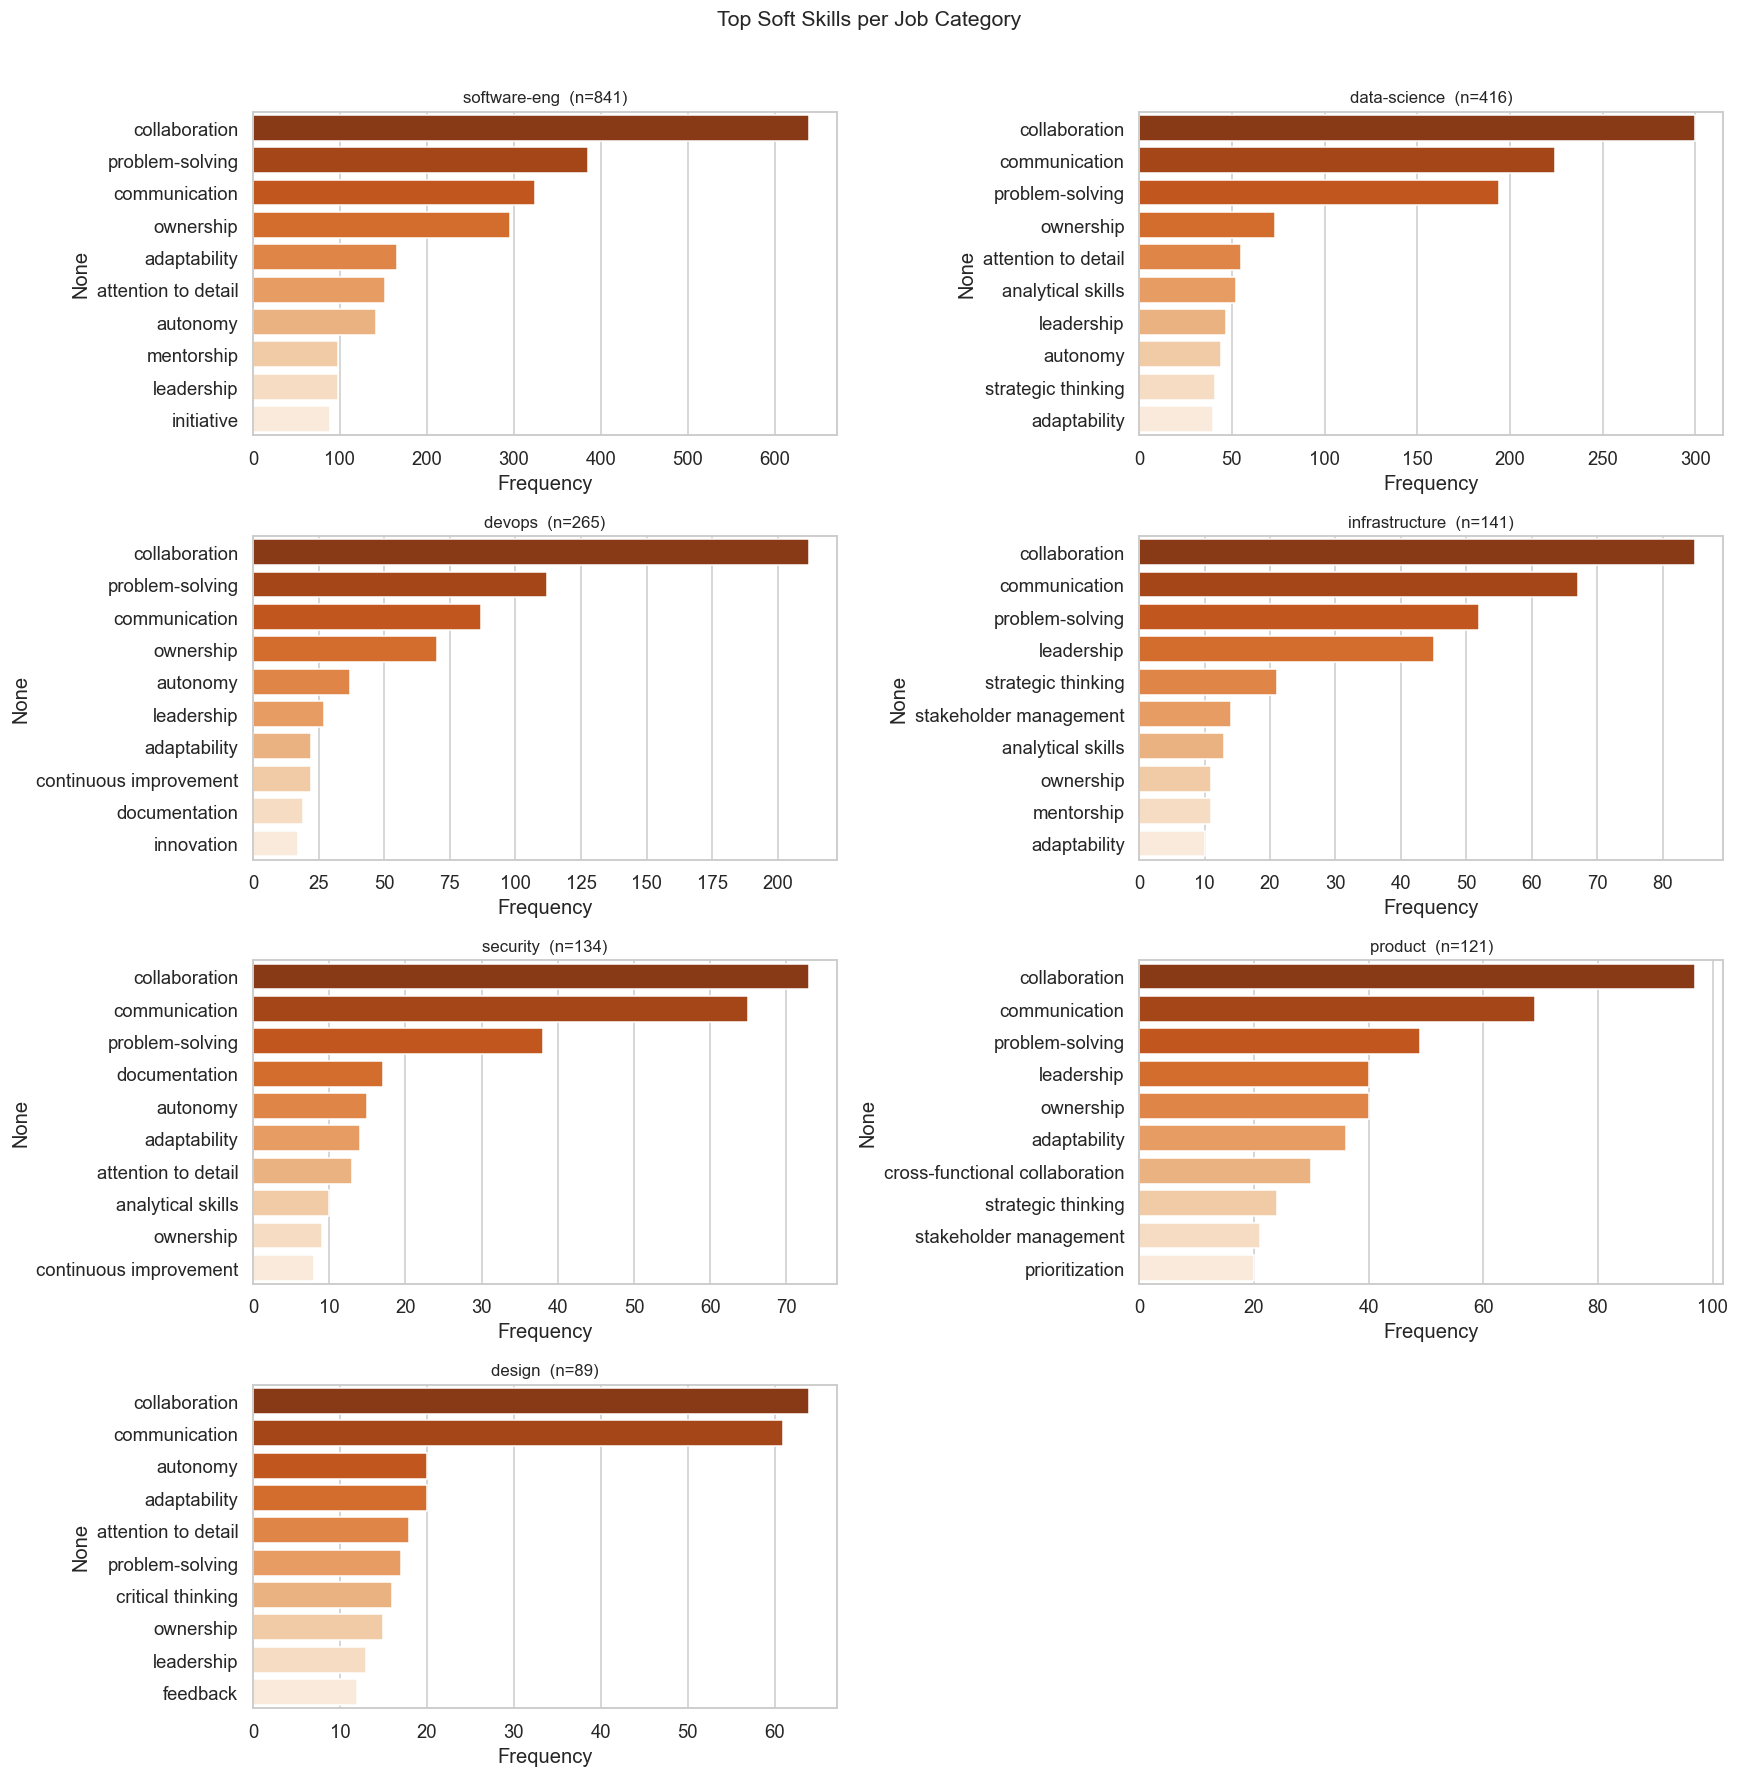

In [16]:
categories = df['job_category'].value_counts().index.tolist()
n_cols = 2
n_rows = -(-len(categories) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, cat in enumerate(categories):
    sub = df[df['job_category'] == cat]
    top = top_n(sub['soft_skills'], n=10)
    if len(top) == 0:
        axes[i].set_visible(False)
        continue
    sns.barplot(x=top.values, y=top.index, ax=axes[i], palette='Oranges_r')
    axes[i].set_title(f'{cat}  (n={len(sub):,})', fontsize=11)
    axes[i].set_xlabel('Frequency')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top Soft Skills per Job Category', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Category Signature Skills

Skills where ≥55 % of all appearances are concentrated in one category —
these are the skills that **define** each field.

In [17]:
total_hard = Counter(parse_skills(df['hard_skills']))
cat_cnt = {
    cat: Counter(parse_skills(df[df['job_category'] == cat]['hard_skills']))
    for cat in df['job_category'].unique()
}

signature = {}
for cat, counter in cat_cnt.items():
    sigs = []
    for sk, cnt in counter.items():
        total = total_hard[sk]
        if total >= 5 and cnt / total >= 0.55:
            sigs.append({'skill': sk, 'count': cnt, 'pct': round(cnt / total * 100)})
    signature[cat] = sorted(sigs, key=lambda x: -x['count'])[:12]

print('=== Signature Skills per Category (≥55% concentration) ===\n')
for cat, sigs in signature.items():
    if sigs:
        print(f'{cat}:')
        for s in sigs[:8]:
            print(f'  {s["skill"]:<40} {s["count"]:>3} postings  ({s["pct"]}% in this cat)')
        print()

=== Signature Skills per Category (≥55% concentration) ===

software-eng:
  react                                    250 postings  (94% in this cat)
  typescript                               231 postings  (95% in this cat)
  javascript                               228 postings  (89% in this cat)
  system design                            183 postings  (63% in this cat)
  java                                     179 postings  (74% in this cat)
  performance optimization                 169 postings  (71% in this cat)
  code review                              153 postings  (85% in this cat)
  agile                                    133 postings  (62% in this cat)

devops:
  terraform                                160 postings  (73% in this cat)
  kubernetes                               147 postings  (57% in this cat)
  observability                             90 postings  (62% in this cat)
  bash                                      80 postings  (87% in this cat)
  linux          

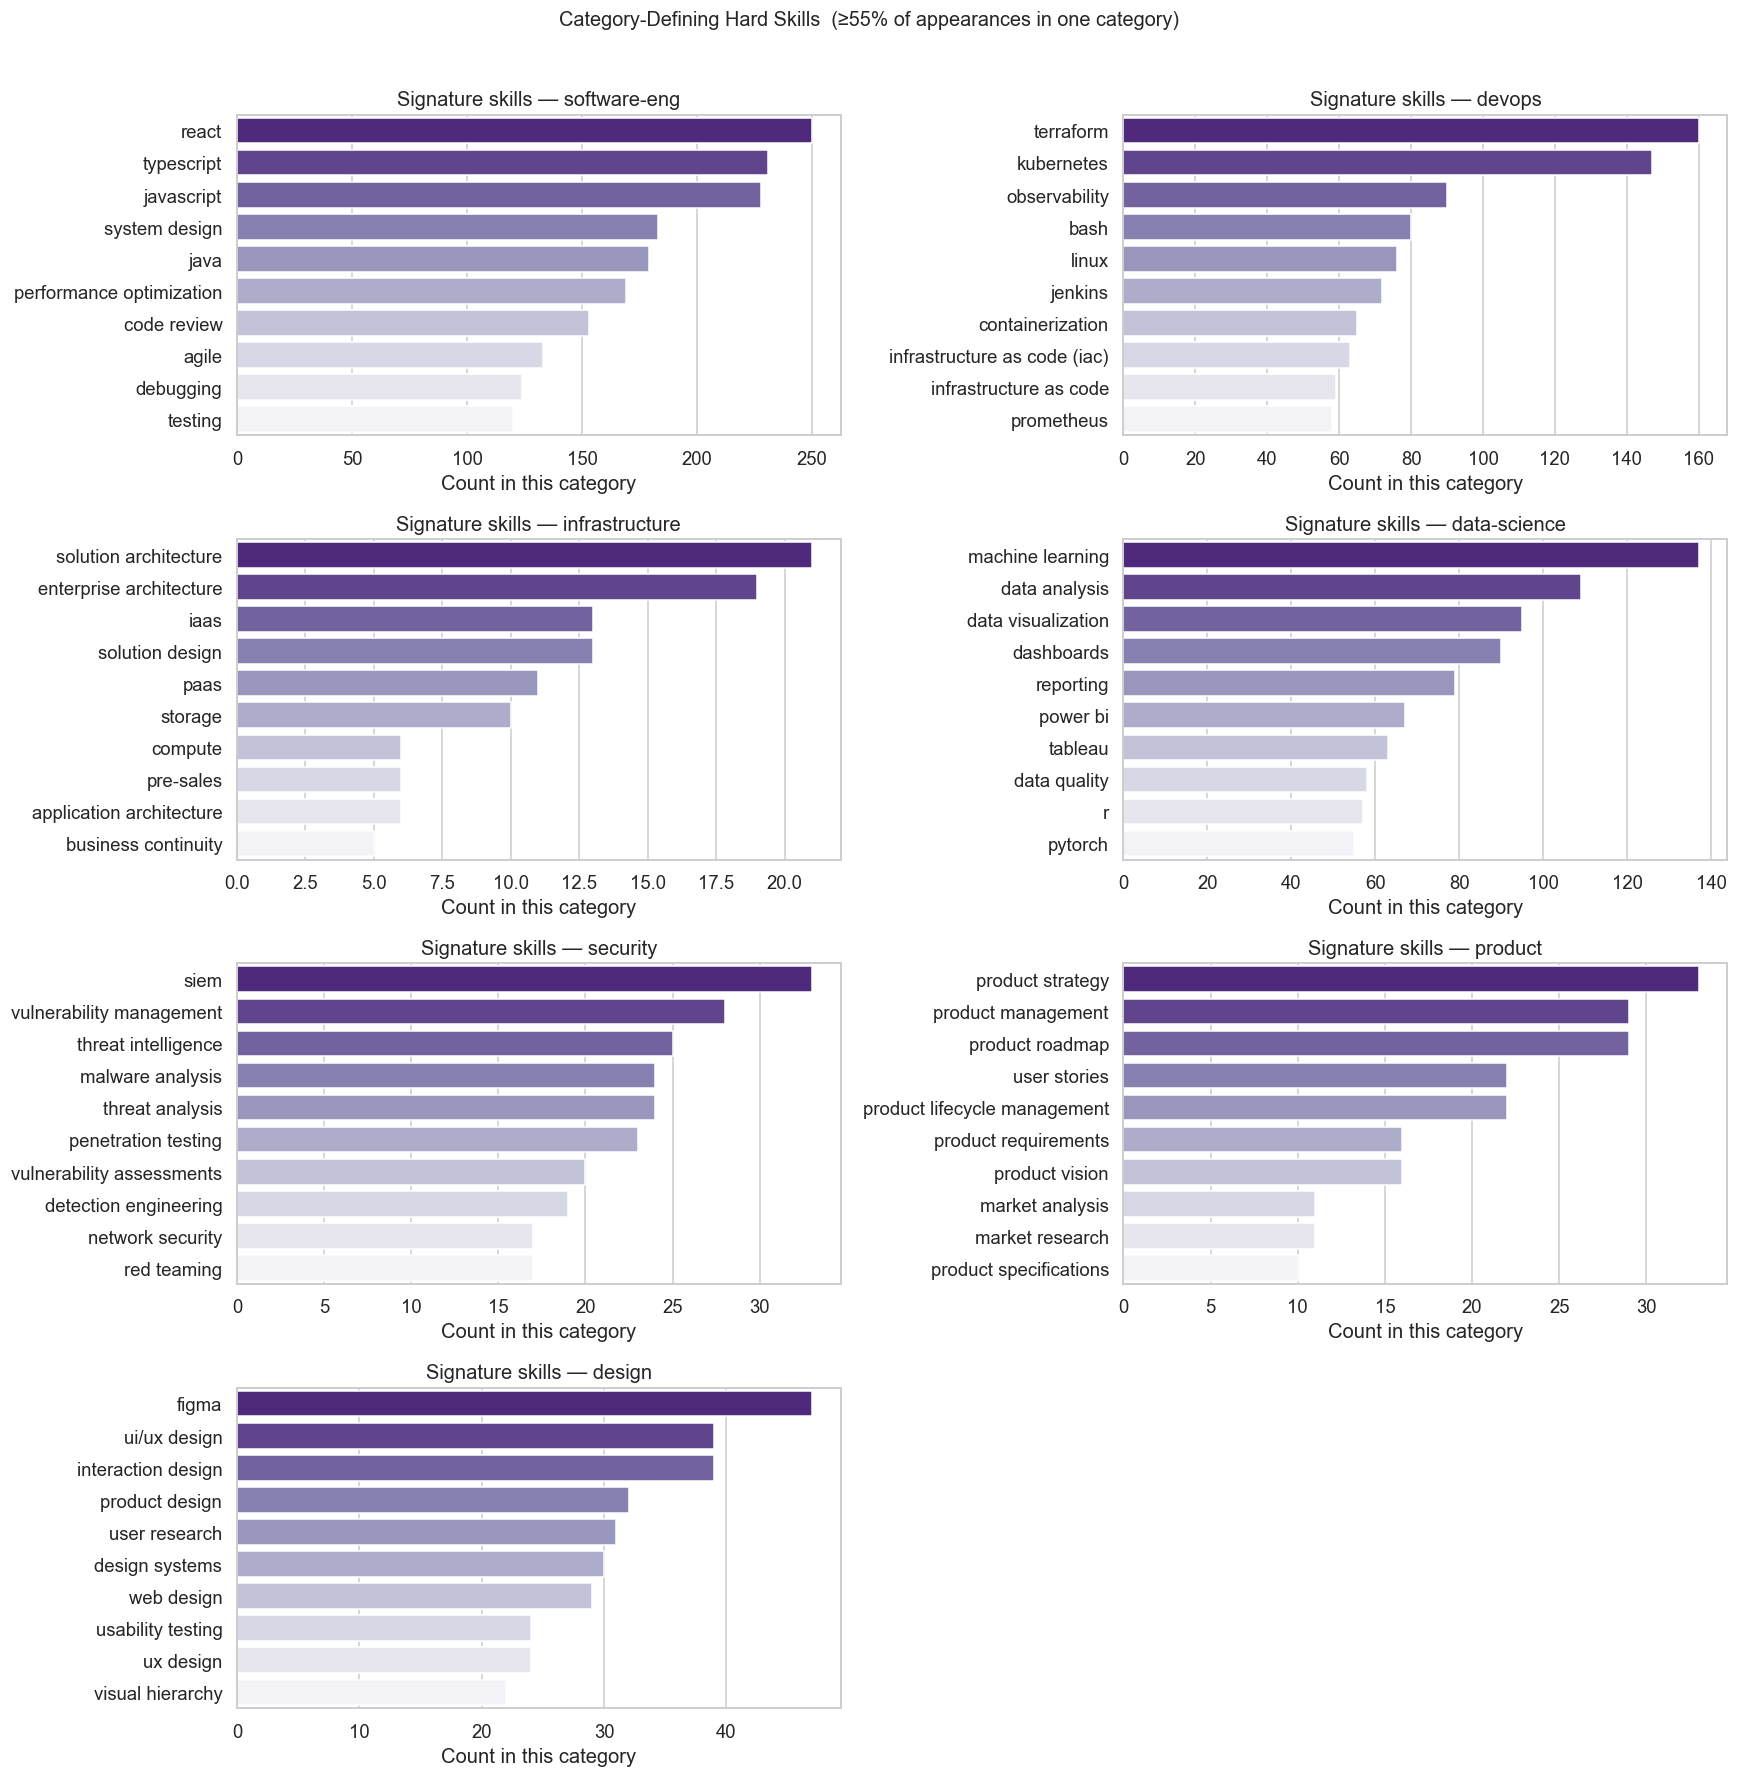

In [18]:
cats_with_sigs = {cat: sigs for cat, sigs in signature.items() if sigs}
n_cols = 2
n_rows = -(-len(cats_with_sigs) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, (cat, sigs) in enumerate(cats_with_sigs.items()):
    labels = [s['skill'] for s in sigs[:10]]
    values = [s['count'] for s in sigs[:10]]
    sns.barplot(x=values, y=labels, ax=axes[i], palette='Purples_r')
    axes[i].set_title(f'Signature skills — {cat}')
    axes[i].set_xlabel('Count in this category')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Category-Defining Hard Skills  (≥55% of appearances in one category)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 8. Skills Co-occurrence Heatmap

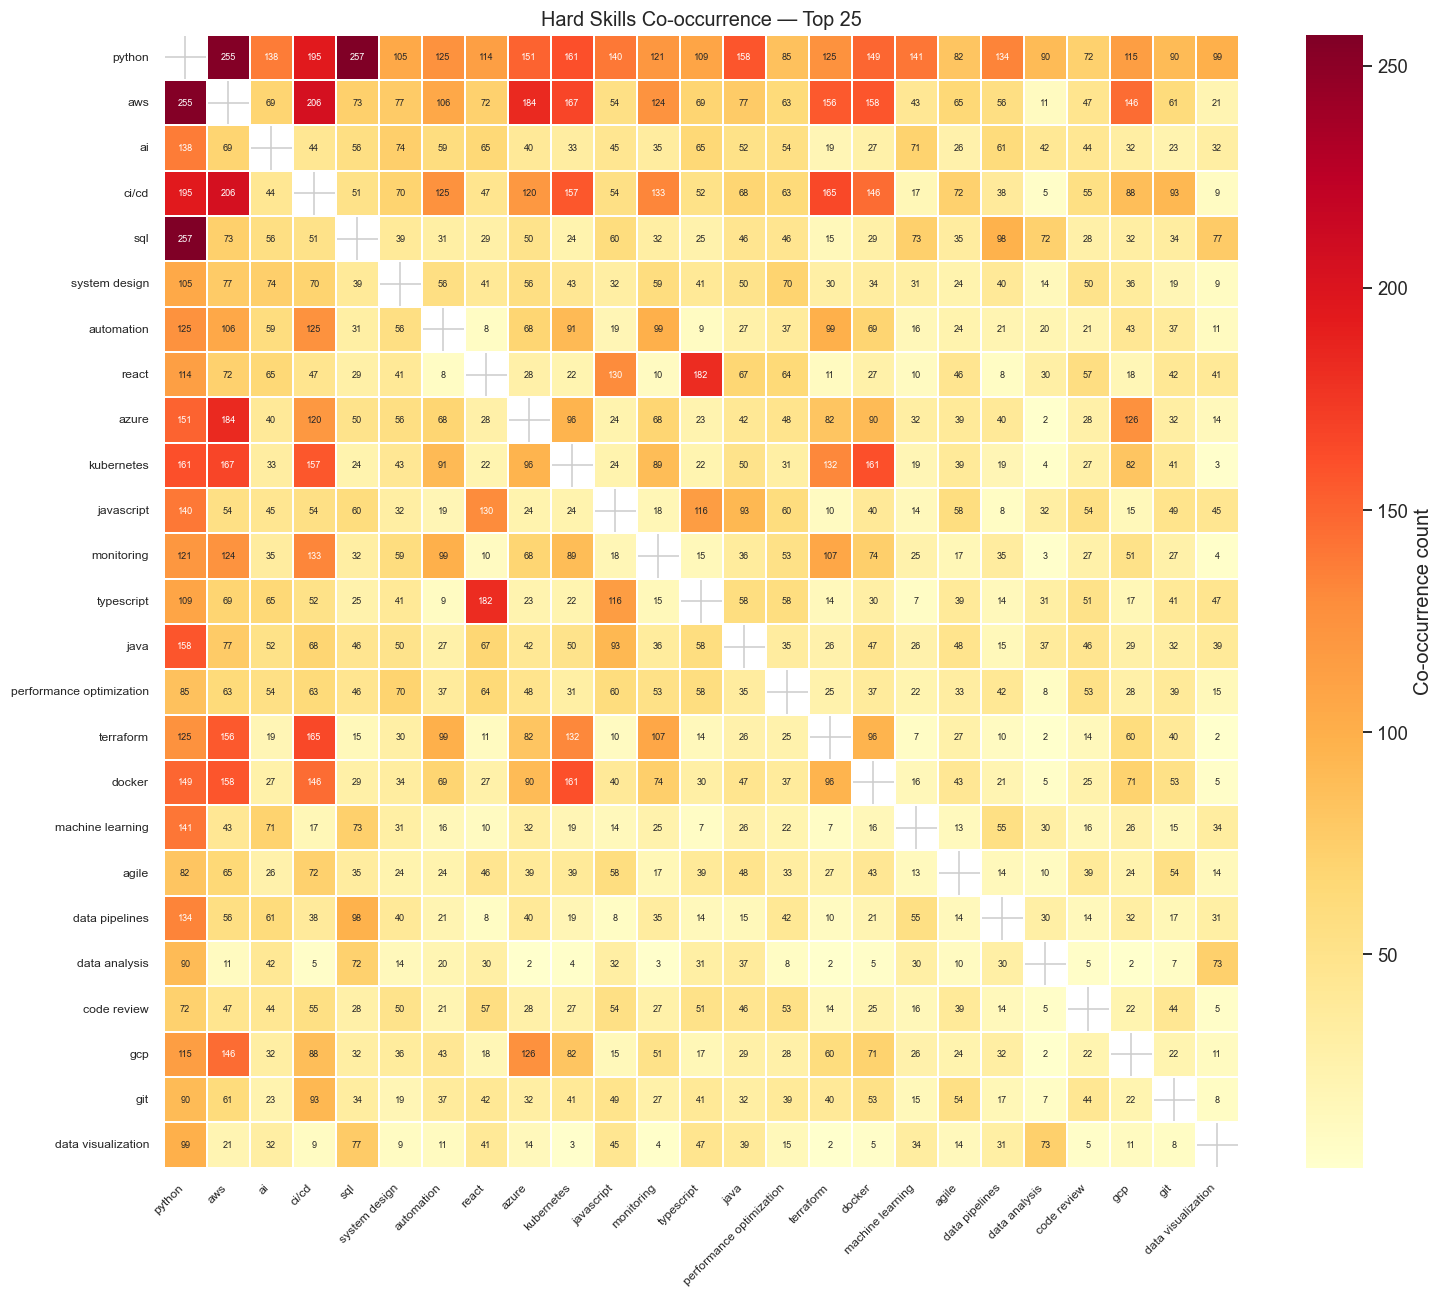

In [19]:
top25_skills = [k for k, _ in Counter(parse_skills(df['hard_skills'])).most_common(25)]
n = len(top25_skills)
cooc = np.zeros((n, n), dtype=int)

for cell in df['hard_skills'].dropna():
    row_sk = {s.strip().lower() for s in str(cell).split(',') if s.strip()}
    idxs   = [i for i, sk in enumerate(top25_skills) if sk in row_sk]
    for a_i in idxs:
        for b_i in idxs:
            if a_i != b_i:
                cooc[a_i][b_i] += 1

cooc_df = pd.DataFrame(cooc, index=top25_skills, columns=top25_skills)

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.eye(n, dtype=bool)
sns.heatmap(cooc_df, mask=mask, cmap='YlOrRd', ax=ax,
            linewidths=0.3, annot=True, fmt='d', annot_kws={'size': 6},
            cbar_kws={'label': 'Co-occurrence count'})
ax.set_title('Hard Skills Co-occurrence — Top 25', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

---
## 9. Location & Remote Trends

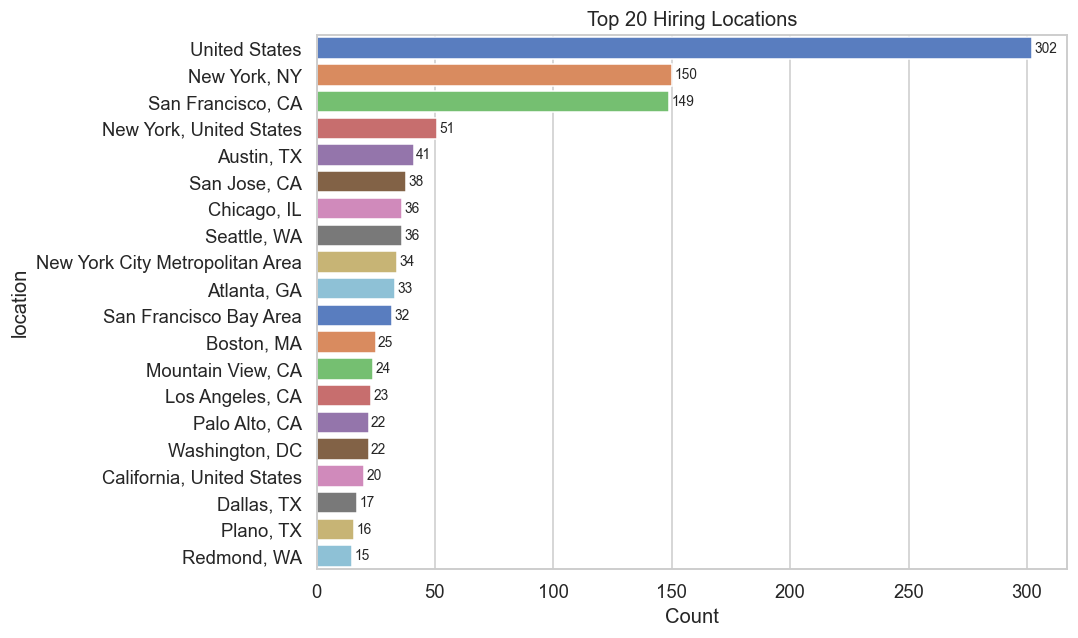

In [20]:
loc = df['location'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=loc.values, y=loc.index, ax=ax, palette='muted')
ax.set_title('Top 20 Hiring Locations')
ax.set_xlabel('Count')
for p, v in zip(ax.patches, loc.values):
    ax.text(p.get_width() + 1, p.get_y() + p.get_height()/2, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

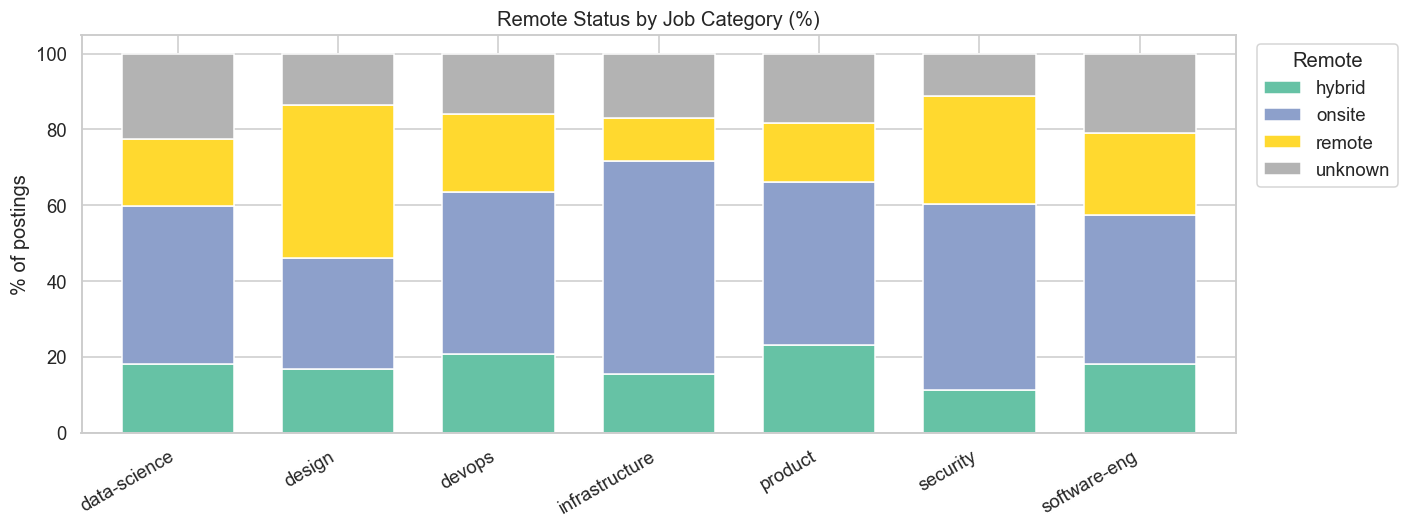


Remote % by category:
remote_status   hybrid  onsite  remote  unknown
job_category                                   
data-science      18.0    41.8    17.5     22.6
design            16.9    29.2    40.4     13.5
devops            20.8    42.6    20.8     15.8
infrastructure    15.6    56.0    11.3     17.0
product           23.1    43.0    15.7     18.2
security          11.2    49.3    28.4     11.2
software-eng      18.1    39.5    21.5     20.9


In [21]:
remote_cat = df.groupby(['job_category', 'remote_status']).size().unstack(fill_value=0)
remote_pct = remote_cat.div(remote_cat.sum(axis=1), axis=0) * 100

ax = remote_pct.plot(kind='bar', stacked=True, figsize=(13, 5),
                     colormap='Set2', width=0.7)
ax.set_title('Remote Status by Job Category (%)')
ax.set_ylabel('% of postings')
ax.set_xlabel('')
ax.legend(title='Remote', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print('\nRemote % by category:')
print(remote_pct.round(1).to_string())

Remote: 418  |  Onsite: 842


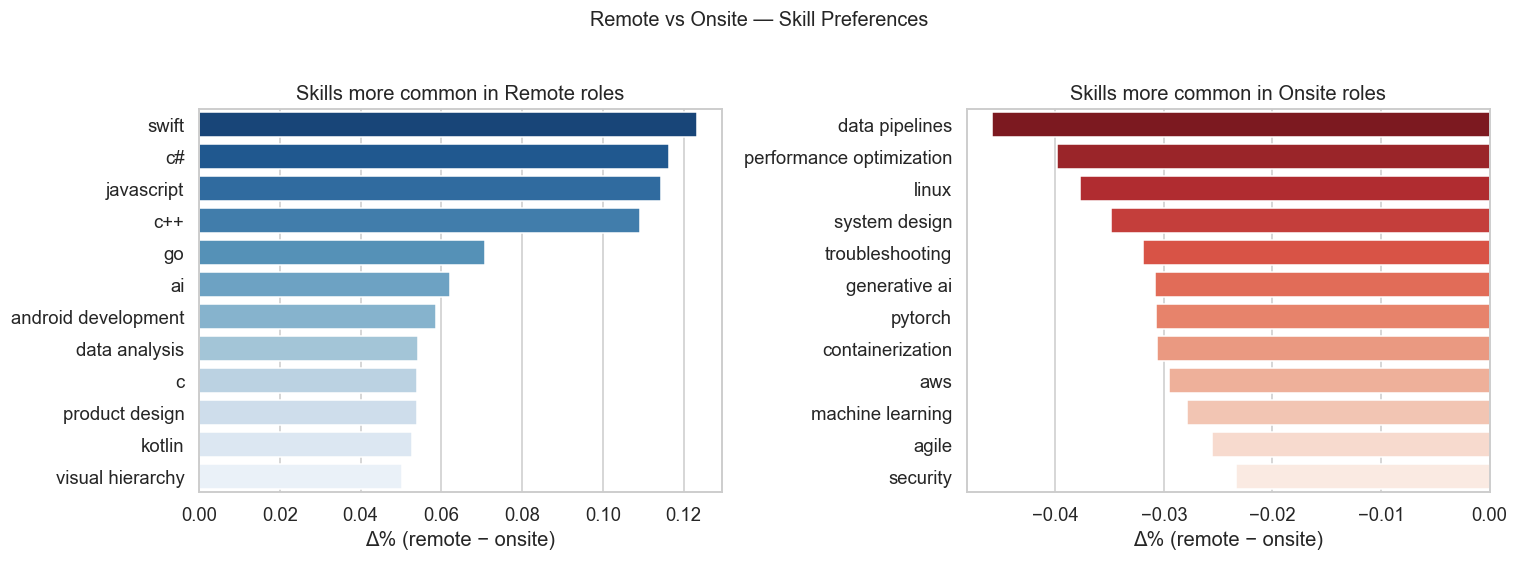

In [22]:
remote_df = df[df['remote_status'] == 'remote']
onsite_df = df[df['remote_status'] == 'onsite']
n_r, n_o   = len(remote_df), len(onsite_df)
print(f'Remote: {n_r}  |  Onsite: {n_o}')

c_r = Counter(parse_skills(remote_df['hard_skills']))
c_o = Counter(parse_skills(onsite_df['hard_skills']))
diff = {}
for sk in set(c_r) | set(c_o):
    r_p = c_r.get(sk, 0) / n_r
    o_p = c_o.get(sk, 0) / n_o
    if r_p + o_p >= 0.02:
        diff[sk] = r_p - o_p

r_lean = sorted(diff.items(), key=lambda x: -x[1])[:12]
o_lean = sorted(diff.items(), key=lambda x:  x[1])[:12]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sk, vals = zip(*r_lean)
sns.barplot(x=list(vals), y=list(sk), ax=axes[0], palette='Blues_r')
axes[0].set_title('Skills more common in Remote roles')
axes[0].set_xlabel('Δ% (remote − onsite)')

sk, vals = zip(*o_lean)
sns.barplot(x=list(vals), y=list(sk), ax=axes[1], palette='Reds_r')
axes[1].set_title('Skills more common in Onsite roles')
axes[1].set_xlabel('Δ% (remote − onsite)')

plt.suptitle('Remote vs Onsite — Skill Preferences', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()